ANOVA analysis - sensor position

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - CO2

In [6]:
model = "time independent CO2"
leftlow = pd.read_csv("../_timeindep_results_raw/case_room2_leftlow_state_timeindep_co2.csv")
lefttop = pd.read_csv("../_timeindep_results_raw/case_room2_lefttop_state_timeindep_co2.csv")
rightlow = pd.read_csv("../_timeindep_results_raw/case_room2_rightlow_state_timeindep_co2.csv")
righttop = pd.read_csv("../_timeindep_results_raw/case_room2_righttop_state_timeindep_co2.csv")

In [7]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.965891,0.009801,0.941818,0.960000,0.967273,0.970909,0.989091
f1_weighted,250.0,0.965689,0.009918,0.940520,0.959854,0.966873,0.971158,0.989139
balanced_acc,250.0,0.942014,0.018563,0.877889,0.931743,0.942208,0.956269,0.984541
auc,250.0,0.994733,0.002408,0.984242,0.993351,0.995050,0.996424,0.998937
model_weights.random_forest,250.0,2.207619,0.375639,1.277377,1.977333,2.210079,2.425812,3.536211
model_weights.bagging_svc,250.0,0.812424,0.408434,-0.240708,0.537036,0.830167,1.077966,1.996014
model_weights.bagging_knn,250.0,2.001033,0.330298,0.940056,1.781288,1.982309,2.210934,2.992711
model_weights.gradient_boosting,250.0,1.933906,0.379613,0.959709,1.720405,1.943544,2.174397,3.328599


In [8]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.956233,0.011638,0.923636,0.949091,0.956364,0.963636,0.981818
f1_weighted,250.0,0.955903,0.011912,0.922610,0.948425,0.956042,0.963792,0.981908
balanced_acc,250.0,0.926331,0.022791,0.851303,0.911999,0.928540,0.942975,0.974694
auc,250.0,0.989402,0.004436,0.974419,0.986768,0.989717,0.992726,0.998963
model_weights.random_forest,250.0,2.717388,0.364399,1.626271,2.507636,2.727103,2.960892,3.877464
model_weights.bagging_svc,250.0,1.783660,0.324613,0.748721,1.571396,1.796431,2.008731,2.535149
model_weights.bagging_knn,250.0,0.925843,0.291123,0.008364,0.732152,0.946365,1.113242,1.830793
model_weights.gradient_boosting,250.0,1.121098,0.448089,-0.077188,0.846576,1.136105,1.447630,2.266582


In [9]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.962036,0.010428,0.934545,0.952727,0.963636,0.970000,0.989091
f1_weighted,250.0,0.961654,0.010662,0.933120,0.952982,0.963086,0.969390,0.989052
balanced_acc,250.0,0.932775,0.020823,0.877889,0.920455,0.932250,0.947773,0.979219
auc,250.0,0.990875,0.004242,0.976761,0.988303,0.991408,0.994014,0.998157
model_weights.random_forest,250.0,2.502817,0.420588,1.239065,2.211993,2.533980,2.811712,3.574115
model_weights.bagging_svc,250.0,1.156022,0.402232,-0.018755,0.862553,1.163042,1.438970,2.207918
model_weights.bagging_knn,250.0,1.967536,0.346702,0.831654,1.747011,1.958556,2.188757,3.312598
model_weights.gradient_boosting,250.0,0.871636,0.548708,-0.766310,0.521171,0.840706,1.230800,2.429754


In [10]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.965047,0.009781,0.934545,0.960000,0.967273,0.970909,0.989091
f1_weighted,250.0,0.964864,0.009935,0.933207,0.958896,0.966924,0.971059,0.989063
balanced_acc,250.0,0.941737,0.018988,0.877889,0.928943,0.942989,0.956390,0.982671
auc,250.0,0.993132,0.003206,0.973536,0.991463,0.993560,0.995429,0.998741
model_weights.random_forest,250.0,2.250152,0.424640,0.934966,1.962261,2.273562,2.521181,3.255318
model_weights.bagging_svc,250.0,1.927668,0.328380,0.981771,1.681764,1.961725,2.151053,2.761362
model_weights.bagging_knn,250.0,1.866213,0.333192,0.765212,1.652609,1.895462,2.075028,2.818200
model_weights.gradient_boosting,250.0,0.732718,0.476475,-0.605213,0.398320,0.766238,1.046540,2.062774


In [11]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [12]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.970909,0.978182,0.974545,0.96,0.970909
f1_weighted,0.970909,0.978331,0.974772,0.959008,0.97021
balanced_acc,0.953255,0.972432,0.971477,0.916465,0.9375
auc,0.994731,0.996313,0.997175,0.993964,0.996964
x,0,0,0,0,0
x_jitter,-0.07854,0.019807,0.017716,-0.005042,0.070922


### plot

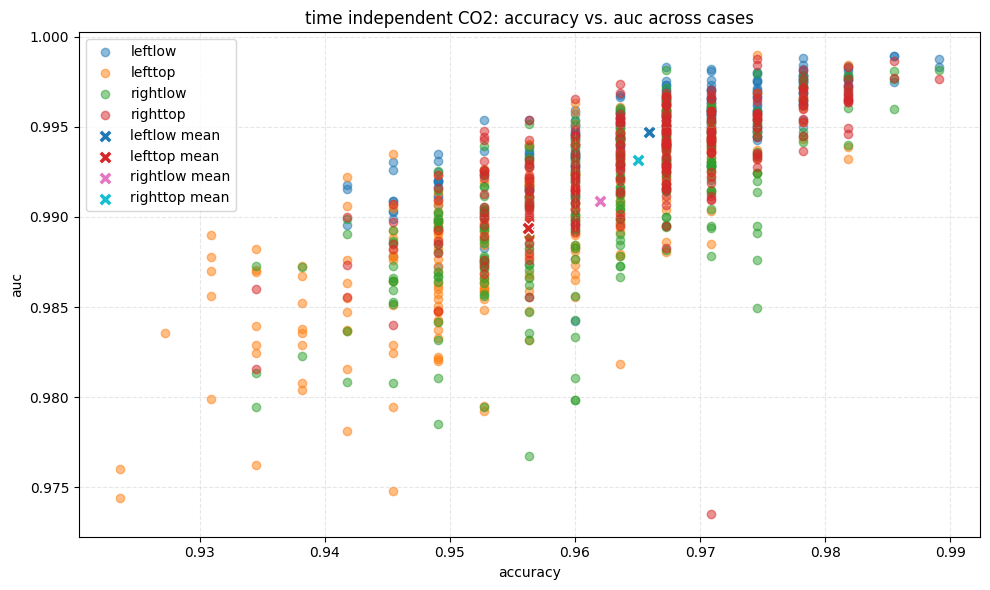

In [13]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

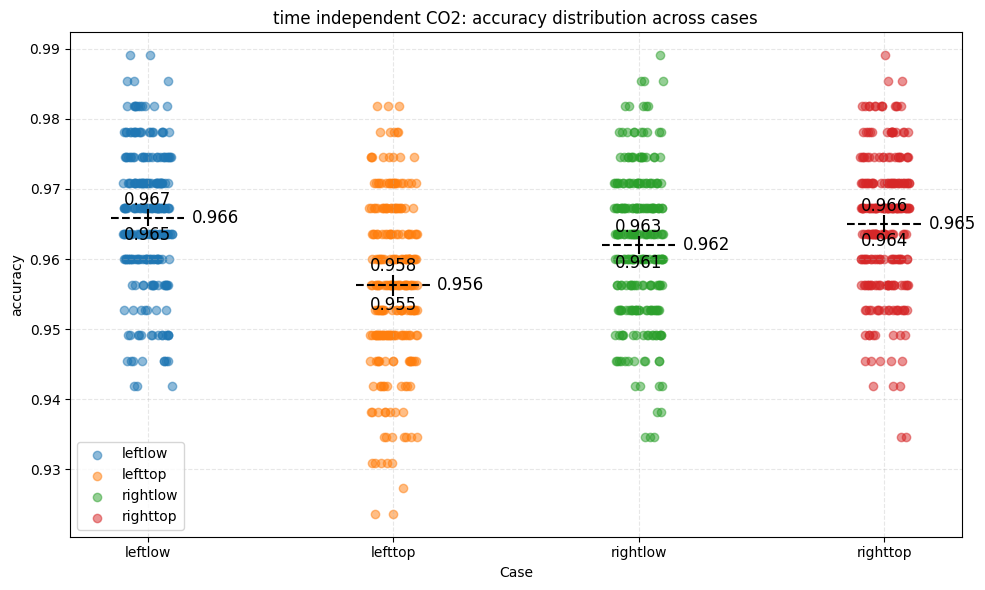

In [14]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

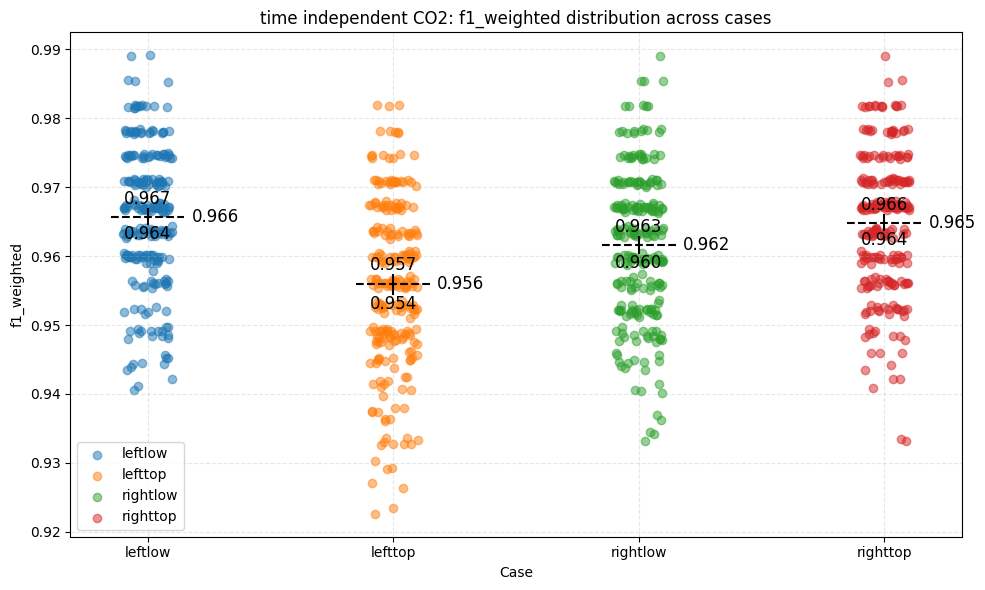

In [15]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

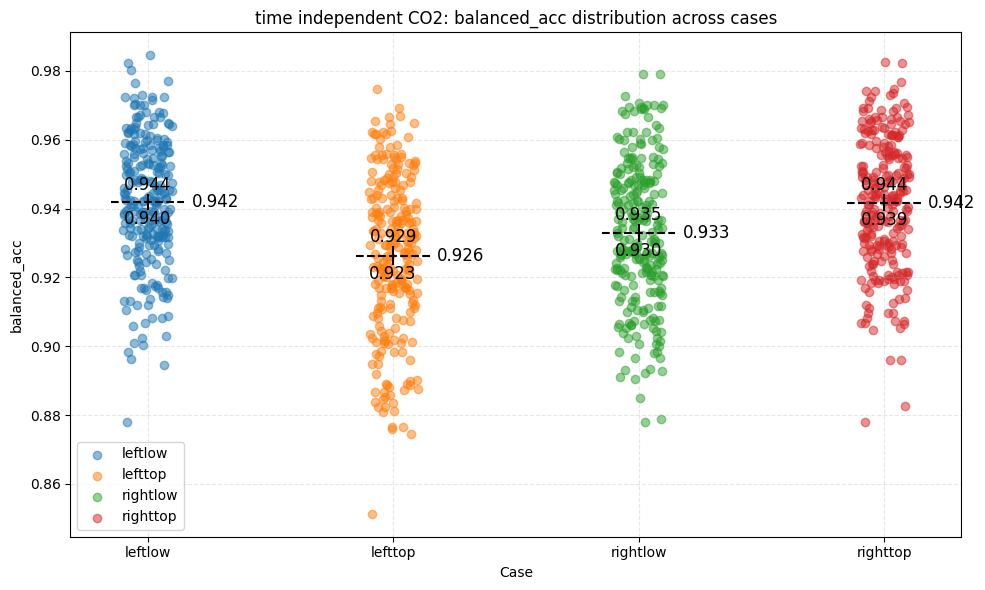

In [16]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

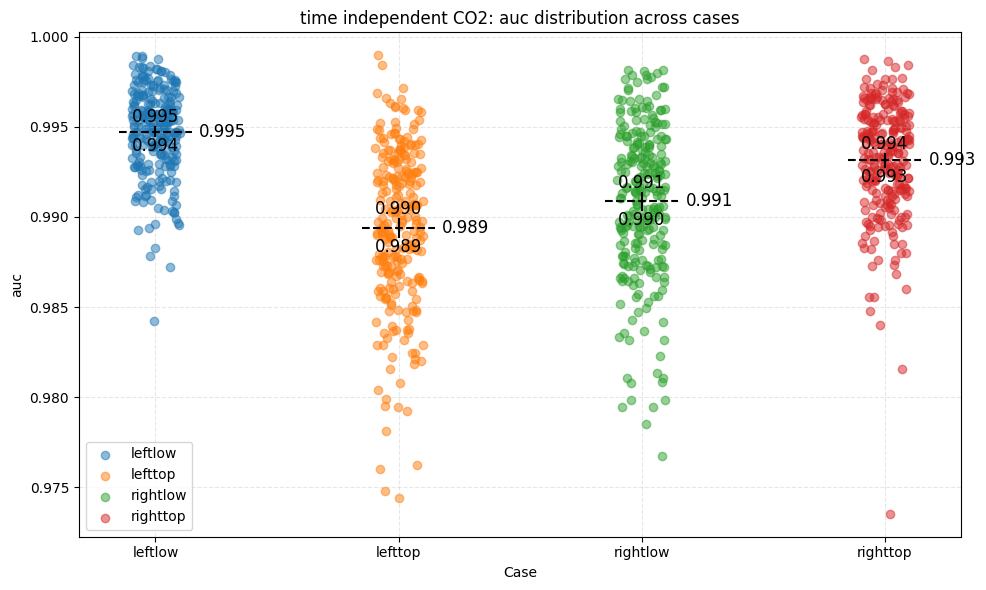

In [17]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.1545	→	OK normal
lefttop                  :	p = 0.2340	→	OK normal
rightlow                 :	p = 0.4973	→	OK normal
righttop                 :	p = 0.1727	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0004	→	not normal
lefttop                  :	p = 0.0055	→	not normal
rightlow                 :	p = 0.0101	→	not normal
righttop                 :	p = 0.0012	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 2.0808,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.3769,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.6131,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 1.9705,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0244	→	unequal variances
Bartlett’

In [19]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
leftlow                  :	p = 0.1364	→	OK normal
lefttop                  :	p = 0.1612	→	OK normal
rightlow                 :	p = 0.4306	→	OK normal
righttop                 :	p = 0.1336	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
leftlow                  :	p = 0.0036	→	not normal
lefttop                  :	p = 0.0250	→	not normal
rightlow                 :	p = 0.1011	→	OK normal
righttop                 :	p = 0.0092	→	not normal

=== Normality test (Anderson-Darling) for f1_weighted ===
leftlow                  :	A² = 1.3983,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 0.8069,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.9423,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 1.2799,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.0146	→	unequal variance

In [20]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0655	→	OK normal
lefttop                  :	p = 0.0272	→	not normal
rightlow                 :	p = 0.1126	→	OK normal
righttop                 :	p = 0.0835	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0654	→	OK normal
lefttop                  :	p = 0.0031	→	not normal
rightlow                 :	p = 0.1581	→	OK normal
righttop                 :	p = 0.0154	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 0.5982,	5% critical = 0.7750	→	OK normal
lefttop                  :	A² = 1.0970,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.4463,	5% critical = 0.7750	→	OK normal
righttop                 :	A² = 0.7056,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0040	→	unequal varianc

### ANOVA

In [21]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0001	→	not normal
rightlow                 :	p = 0.0001	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0001	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 2.0246,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.4416,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.5291,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 2.2641,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.00

In [22]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 552.241736 39.572271 3.552521e-23 0.116631

Effect size (partial η², np2) = 0.1166 → medium effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.965891 0.956233  0.009658 0.000962 10.036346 483.988266 0.000000e+00  0.896325
 leftlow rightlow 0.965891 0.962036  0.003855 0.000905  4.258718 496.099417 1.441812e-04  0.380337
 leftlow righttop 0.965891 0.965047  0.000844 0.000876  0.963359 497.997830 7.703335e-01  0.086036
 lefttop rightlow 0.956233 0.962036 -0.005804 0.000988 -5.872257 492.109678 4.742732e-08 -0.524439
 lefttop righttop 0.956233 0.965047 -0.008815 0.000961 -9.167604 483.662224 1.071365e-13 -0.818740
rightlow righttop 0.962036 0.965047 -0.003011 0.000904 -3.329876 495.970117 5.150785e-03 -0.297384

=== Pairwise effect sizes for ac

In [23]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 552.114081 39.302744 4.947877e-23 0.115885

Effect size (partial η², np2) = 0.1159 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.965689 0.955903  0.009786 0.000980  9.981742 482.166674 0.000000e+00  0.891449
 leftlow rightlow 0.965689 0.961654  0.004035 0.000921  4.380864 495.414750 8.493567e-05  0.391246
 leftlow righttop 0.965689 0.964864  0.000825 0.000888  0.929313 497.998494 7.891386e-01  0.082995
 lefttop rightlow 0.955903 0.961654 -0.005751 0.001011 -5.687695 492.001294 1.323999e-07 -0.507956
 lefttop righttop 0.955903 0.964864 -0.008961 0.000981 -9.133592 482.450170 1.393330e-13 -0.815702
rightlow righttop 0.961654 0.964864 -0.003210 0.000922 -3.482154 495.536496 3.031991e-03 -0.310984

=== Pairwise effect sizes 

In [24]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc     np2
  case      3 551.827995 32.821284 1.562838e-19 0.09464

Effect size (partial η², np2) = 0.0946 → medium effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 leftlow  lefttop 0.942014 0.926331  0.015683 0.001859  8.435846 478.405361 0.000000  0.753388
 leftlow rightlow 0.942014 0.932775  0.009238 0.001764  5.236236 491.566614 0.000001  0.467638
 leftlow righttop 0.942014 0.941737  0.000277 0.001679  0.164730 497.745402 0.998408  0.014712
 lefttop rightlow 0.926331 0.932775 -0.006444 0.001952 -3.300638 493.992789 0.005689 -0.294773
 lefttop righttop 0.926331 0.941737 -0.015406 0.001876 -8.211601 482.271525 0.000000 -0.733361
rightlow righttop 0.932775 0.941737 -0.008962 0.001782 -5.028173 493.818290 0.000004 -0.449056

=== Pairwise effect sizes for balanced_acc (Hedges' g)

In [25]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 537.275415 118.728451 5.405738e-59 0.238429

Effect size (partial η², np2) = 0.2384 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.994733 0.989402  0.005331 0.000319  16.699980 383.966639 0.000000e+00  1.491441
 leftlow rightlow 0.994733 0.990875  0.003858 0.000308  12.506418 394.347459 1.398881e-13  1.116923
 leftlow righttop 0.994733 0.993132  0.001602 0.000254   6.317154 462.087872 3.759582e-09  0.564172
 lefttop rightlow 0.989402 0.990875 -0.001473 0.000388  -3.795051 497.002627 9.508024e-04 -0.338928
 lefttop righttop 0.989402 0.993132 -0.003729 0.000346 -10.773158 453.338803 2.772227e-13 -0.962129
rightlow righttop 0.990875 0.993132 -0.002256 0.000336  -6.709101 463.479334 3.433664e-10 -0.599176

=== Pairwise effect sizes for auc 

## Time series - CO2

In [27]:
model = "time series CO2"
leftlow = pd.read_csv("../_timeseries_results_raw/case_room2_leftlow_state_timeseries_co2.csv")
lefttop = pd.read_csv("../_timeseries_results_raw/case_room2_lefttop_state_timeseries_co2.csv")
rightlow = pd.read_csv("../_timeseries_results_raw/case_room2_rightlow_state_timeseries_co2.csv")
righttop = pd.read_csv("../_timeseries_results_raw/case_room2_righttop_state_timeseries_co2.csv")

In [28]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.911346,0.019635,0.856031,0.902724,0.914397,0.926070,0.957198
f1,250.0,0.888191,0.022335,0.826291,0.877148,0.891192,0.903553,0.943005
balanced_acc,250.0,0.926389,0.016733,0.878261,0.919433,0.930303,0.936989,0.964262
auc,250.0,0.978894,0.015676,0.875758,0.978821,0.982938,0.985935,0.992424
feature_importance.leftlow_CO2_scaled,250.0,0.115314,0.075288,0.005837,0.055058,0.104280,0.162646,0.337743
feature_importance.leftlow_CO2_fd1_scaled,250.0,0.129121,0.045750,-0.004280,0.114883,0.135214,0.156420,0.226459
feature_importance.leftlow_CO2_fd2_scaled,250.0,0.108487,0.042472,-0.010895,0.088327,0.111284,0.134922,0.212062
feature_importance.leftlow_CO2_fd3_scaled,250.0,0.078954,0.038190,-0.011673,0.056615,0.082101,0.100681,0.240856


In [29]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.866459,0.041479,0.797665,0.821012,0.891051,0.898833,0.933852
f1,250.0,0.824220,0.060710,0.714286,0.755319,0.862745,0.873477,0.910995
balanced_acc,250.0,0.870676,0.052005,0.777503,0.810112,0.904644,0.912220,0.936462
auc,250.0,0.945296,0.024295,0.888406,0.919401,0.956818,0.968083,0.978722
feature_importance.lefttop_CO2_scaled,250.0,0.004825,0.007598,-0.011284,-0.000681,0.003891,0.008463,0.040078
feature_importance.lefttop_CO2_fd1_scaled,250.0,0.133295,0.109981,0.002724,0.019455,0.159533,0.231420,0.342412
feature_importance.lefttop_CO2_fd2_scaled,250.0,0.108288,0.089145,0.001556,0.018385,0.115953,0.183755,0.309728
feature_importance.lefttop_CO2_fd3_scaled,250.0,0.071795,0.063508,-0.001556,0.014105,0.059728,0.118288,0.261089


In [30]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.894375,0.022138,0.852590,0.888446,0.900398,0.908367,0.956175
f1,250.0,0.871927,0.024202,0.826291,0.862939,0.878638,0.887805,0.941176
balanced_acc,250.0,0.911774,0.019422,0.874487,0.905079,0.917231,0.924528,0.956248
auc,250.0,0.965501,0.019819,0.886109,0.962734,0.972860,0.976945,0.990156
feature_importance.rightlow_CO2_scaled,250.0,0.005519,0.008064,-0.017131,0.000498,0.003984,0.009064,0.037849
feature_importance.rightlow_CO2_fd1_scaled,250.0,0.127535,0.069624,-0.005578,0.111355,0.148008,0.170418,0.273705
feature_importance.rightlow_CO2_fd2_scaled,250.0,0.099372,0.058411,-0.005976,0.073606,0.110956,0.140239,0.278486
feature_importance.rightlow_CO2_fd3_scaled,250.0,0.067822,0.046226,-0.012351,0.034661,0.071514,0.103386,0.196016


In [31]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
accuracy,250.0,0.775251,0.104519,0.621514,6.334661e-01,0.828685,0.856574,0.940239
f1,250.0,0.532135,0.373404,0.000000,0.000000e+00,0.759375,0.828499,0.922280
balanced_acc,250.0,0.730211,0.169050,0.500000,5.000000e-01,0.810381,0.874487,0.945960
auc,250.0,0.923129,0.038525,0.834017,9.000889e-01,0.930168,0.946455,0.985576
feature_importance.righttop_CO2_scaled,250.0,0.050429,0.065128,-0.016733,-1.110223e-16,0.021116,0.090139,0.298008
feature_importance.righttop_CO2_fd1_scaled,250.0,0.045893,0.087000,-0.022311,-1.110223e-16,0.007968,0.026494,0.400000
feature_importance.righttop_CO2_fd2_scaled,250.0,0.039232,0.075297,-0.039841,-1.110223e-16,0.006574,0.029283,0.361753
feature_importance.righttop_CO2_fd3_scaled,250.0,0.034433,0.069488,-0.041434,-1.110223e-16,0.004582,0.026992,0.355777


In [32]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [33]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.918288,0.856031,0.92607,0.937743,0.92607
f1,0.893401,0.826291,0.904523,0.919192,0.904523
balanced_acc,0.926746,0.878261,0.937615,0.949111,0.937615
auc,0.988076,0.935639,0.988076,0.985837,0.990514
x,0,0,0,0,0
x_jitter,0.076817,0.022666,-0.026905,0.058927,-0.052569


### plot

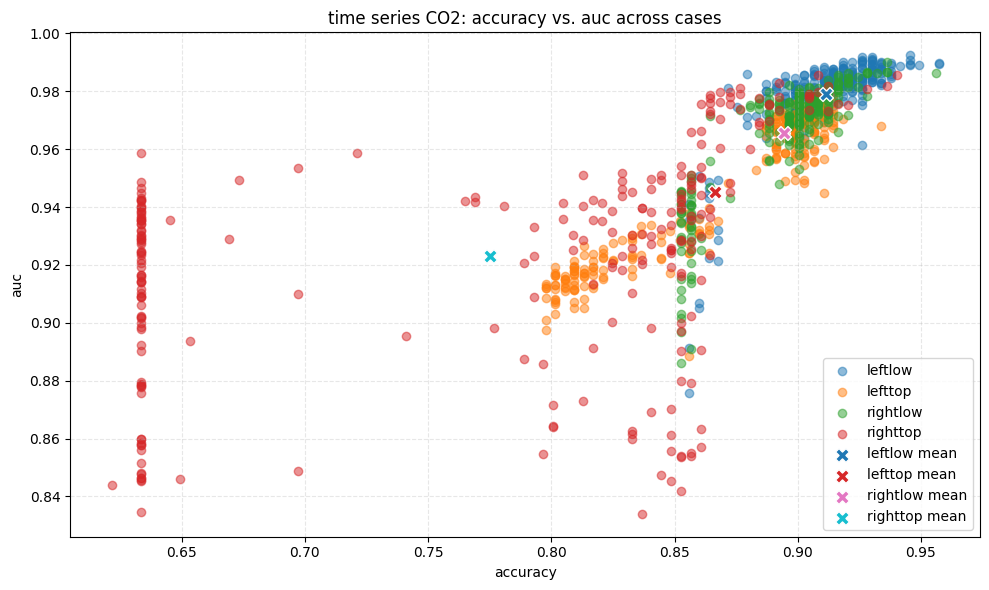

In [34]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

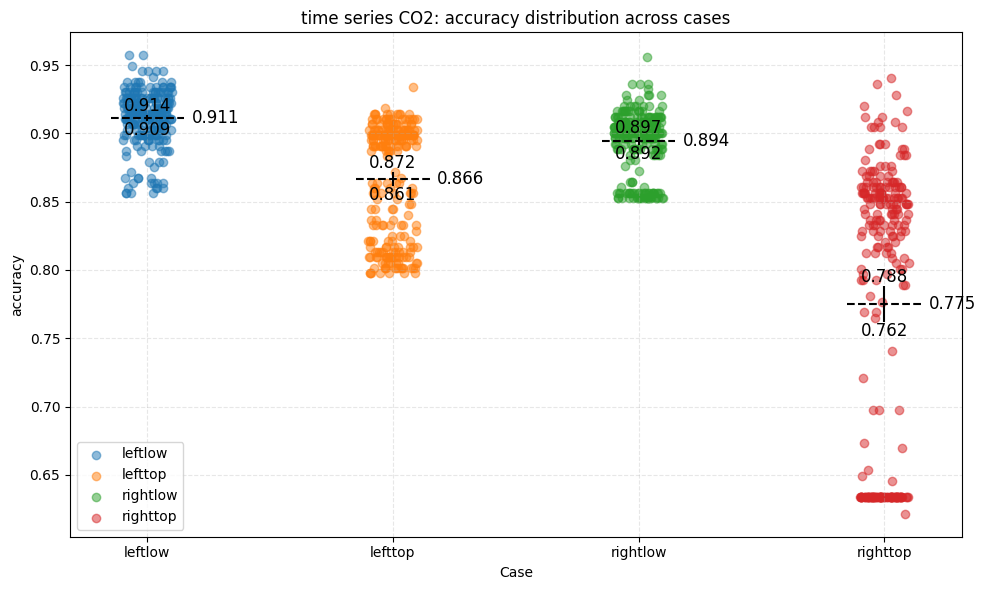

In [35]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

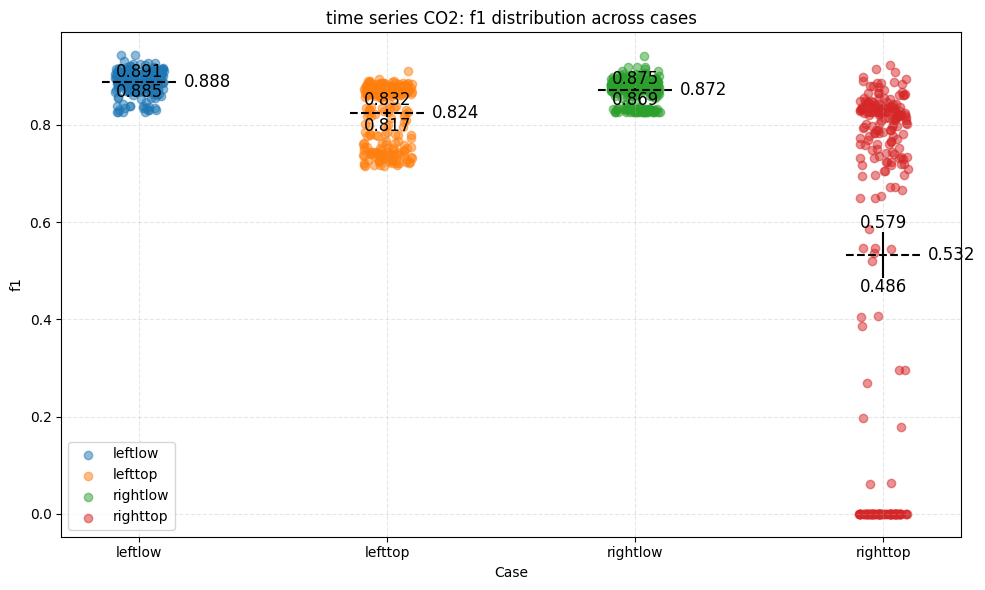

In [36]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

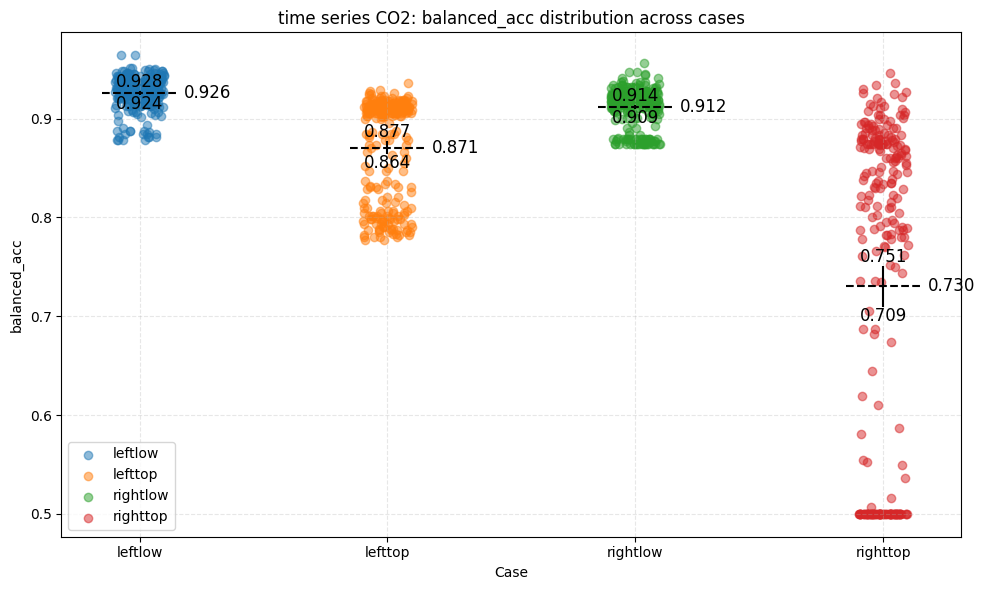

In [37]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

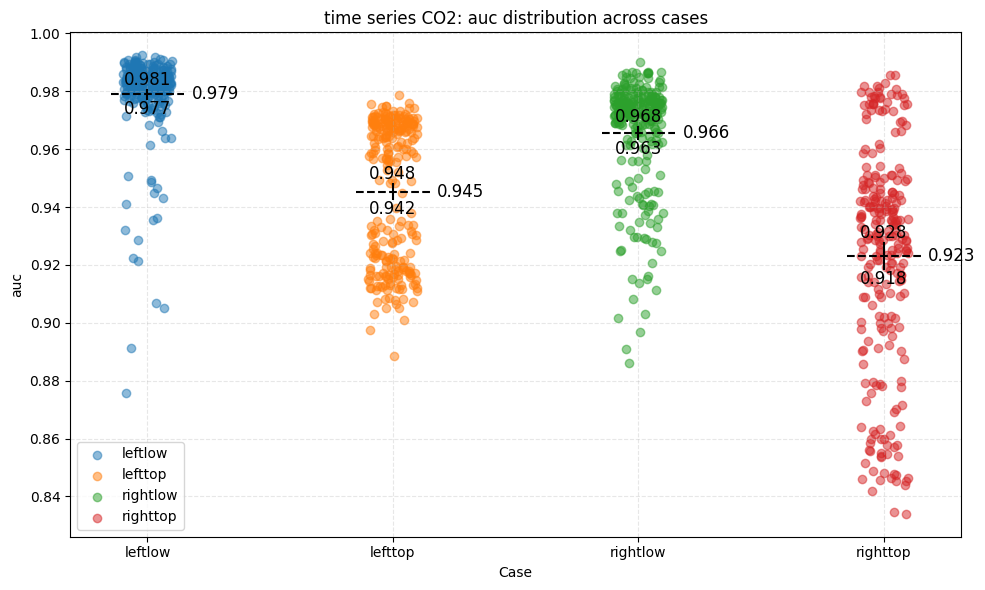

In [38]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0001	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 4.9590,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 17.3157,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 12.9484,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 23.2172,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlet

In [40]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0003	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
leftlow                  :	A² = 4.1270,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 19.7677,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 11.3988,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 32.1503,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→	u

In [41]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 5.5118,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 22.1148,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 11.7421,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 23.2345,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0000	→	unequal v

In [42]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0004	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 33.2850,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 15.0087,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 20.2452,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 4.5665,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000

### ANOVA

In [43]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 518.966294 203.250004 3.678487e-87 0.450233

Effect size (partial η², np2) = 0.4502 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.911346 0.866459  0.044887 0.002902 15.465232 355.251635 2.344791e-13  1.381168
 leftlow rightlow 0.911346 0.894375  0.016972 0.001872  9.068551 490.994943 0.000000e+00  0.809894
 leftlow righttop 0.911346 0.775251  0.136095 0.006726 20.234146 266.552581 0.000000e+00  1.807070
 lefttop rightlow 0.866459 0.894375 -0.027915 0.002974 -9.387565 380.211879 0.000000e+00 -0.838384
 lefttop righttop 0.866459 0.775251  0.091208 0.007112 12.824680 325.534830 0.000000e+00  1.145346
rightlow righttop 0.894375 0.775251  0.119124 0.006757 17.629514 271.297408 1.759703e-13  1.574456

=== Pairwise effect sizes for accura

In [44]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 510.236024 158.045997 1.953730e-72 0.367767

Effect size (partial η², np2) = 0.3678 → large effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.888191 0.824220  0.063971 0.004091  15.636152 315.190939 2.220446e-14  1.396433
 leftlow rightlow 0.888191 0.871927  0.016264 0.002083   7.808296 494.823242 2.354783e-13  0.697343
 leftlow righttop 0.888191 0.532135  0.356056 0.023658  15.049909 250.781707 5.151435e-14  1.344076
 lefttop rightlow 0.824220 0.871927 -0.047707 0.004133 -11.541630 326.195931 0.000000e+00 -1.030759
 lefttop righttop 0.824220 0.532135  0.292085 0.023926  12.207728 262.154837 0.000000e+00  1.090247
rightlow righttop 0.871927 0.532135  0.339793 0.023666  14.358006 251.092085 1.687539e-14  1.282284

=== Pairwise effect sizes for f1 (Hedges'

In [45]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 507.422719 199.405385 2.024972e-85 0.430494

Effect size (partial η², np2) = 0.4305 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.926389 0.870676  0.055713 0.003455  16.124498 300.011967 1.620926e-13  1.440046
 leftlow rightlow 0.926389 0.911774  0.014615 0.001621   9.014007 487.338338 0.000000e+00  0.805022
 leftlow righttop 0.926389 0.730211  0.196178 0.010744  18.259439 253.878935 0.000000e+00  1.630713
 lefttop rightlow 0.870676 0.911774 -0.041098 0.003511 -11.705456 317.132980 1.837419e-13 -1.045390
 lefttop righttop 0.870676 0.730211  0.140465 0.011186  12.557043 295.711229 0.000000e+00  1.121444
rightlow righttop 0.911774 0.730211  0.181563 0.010762  16.870727 255.572239 0.000000e+00  1.506690

=== Pairwise effect s

In [46]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 535.087374 218.097853 2.126862e-92 0.396898

Effect size (partial η², np2) = 0.3969 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.978894 0.945296  0.033598 0.001829  18.373340 425.698189 6.095124e-14  1.640885
 leftlow rightlow 0.978894 0.965501  0.013394 0.001598   8.380517 472.908979 0.000000e+00  0.748447
 leftlow righttop 0.978894 0.923129  0.055765 0.002630  21.199438 329.253554 1.405542e-13  1.893278
 lefttop rightlow 0.945296 0.965501 -0.020205 0.001983 -10.189021 478.690199 1.806333e-13 -0.909961
 lefttop righttop 0.945296 0.923129  0.022167 0.002881   7.695290 420.009316 7.345236e-13  0.687251
rightlow righttop 0.965501 0.923129  0.042371 0.002740  15.463809 372.177595 1.422196e-13  1.381041

=== Pairwise effect sizes for auc (Hedg

## Time independent - CO2temphum

In [47]:
model = "time independent CO2temphum"
leftlow = pd.read_csv("../_timeindep_results_raw/case_room2_leftlow_state_timeindep_co2temphum.csv")
lefttop = pd.read_csv("../_timeindep_results_raw/case_room2_lefttop_state_timeindep_co2temphum.csv")
rightlow = pd.read_csv("../_timeindep_results_raw/case_room2_rightlow_state_timeindep_co2temphum.csv")
righttop = pd.read_csv("../_timeindep_results_raw/case_room2_righttop_state_timeindep_co2temphum.csv")

In [48]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.979491,0.008008,0.952727,0.974545,0.981818,0.985455,0.996364
f1_weighted,250.0,0.979495,0.008014,0.952899,0.974632,0.981630,0.985436,0.996382
balanced_acc,250.0,0.968754,0.014663,0.919139,0.959107,0.970761,0.979516,0.997863
auc,250.0,0.997488,0.001538,0.992670,0.996622,0.997641,0.998636,1.000000
model_weights.random_forest,250.0,3.474963,0.415018,2.551930,3.224364,3.483662,3.756849,4.634972
model_weights.bagging_svc,250.0,0.538313,0.295883,-0.205305,0.354177,0.526137,0.753681,1.416880
model_weights.bagging_knn,250.0,2.015993,0.332131,1.116389,1.770058,2.006815,2.239762,3.208411
model_weights.gradient_boosting,250.0,1.580474,0.495357,0.402188,1.221099,1.599346,1.885257,3.014532


In [49]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.972320,0.008941,0.941818,0.967273,0.974545,0.978182,0.992727
f1_weighted,250.0,0.972512,0.008813,0.942632,0.967377,0.974478,0.978336,0.992780
balanced_acc,250.0,0.963517,0.014237,0.919886,0.953934,0.964928,0.973980,0.995516
auc,250.0,0.995776,0.002255,0.986151,0.994563,0.996202,0.997365,0.999832
model_weights.random_forest,250.0,2.440884,0.348741,1.663573,2.210209,2.416636,2.687042,3.527110
model_weights.bagging_svc,250.0,2.220716,0.279098,1.396113,2.036772,2.220167,2.403837,3.044925
model_weights.bagging_knn,250.0,1.114033,0.290806,0.387065,0.928847,1.110539,1.296749,1.988049
model_weights.gradient_boosting,250.0,1.686178,0.424461,0.599976,1.397314,1.675706,1.960298,3.037329


In [50]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.975636,0.009575,0.941818,0.970909,0.974545,0.981818,0.996364
f1_weighted,250.0,0.975695,0.009609,0.939673,0.970756,0.974997,0.981888,0.996374
balanced_acc,250.0,0.965234,0.017837,0.879084,0.953738,0.966780,0.977846,0.997664
auc,250.0,0.996791,0.001901,0.990313,0.995767,0.997040,0.998136,1.000000
model_weights.random_forest,250.0,2.677750,0.329991,1.776711,2.469659,2.680839,2.896392,3.523257
model_weights.bagging_svc,250.0,1.318686,0.330252,0.534219,1.079196,1.314692,1.547552,2.083960
model_weights.bagging_knn,250.0,1.689002,0.286200,1.027262,1.484581,1.689355,1.898915,2.531216
model_weights.gradient_boosting,250.0,2.076327,0.446759,0.696314,1.796900,2.086261,2.351898,3.323396


In [51]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
accuracy,250.0,0.974735,0.008611,0.952727,9.672727e-01,0.974545,0.981818,0.992727
f1_weighted,250.0,0.974804,0.008584,0.952250,9.679269e-01,0.974820,0.981840,0.992768
balanced_acc,250.0,0.963652,0.014978,0.918357,9.546554e-01,0.965196,0.974694,0.995305
auc,250.0,0.996854,0.001822,0.988519,9.959681e-01,0.997197,0.998210,0.999916
model_weights.random_forest,250.0,2.669498,0.367316,1.665075,2.397222e+00,2.671143,2.945132,3.734700
model_weights.bagging_svc,250.0,1.775921,0.337735,0.859112,1.512624e+00,1.796637,2.005030,2.715566
model_weights.bagging_knn,250.0,1.073633,0.323081,0.237601,8.592002e-01,1.053300,1.275640,2.072741
model_weights.gradient_boosting,250.0,1.918975,0.506772,0.419391,1.607419e+00,1.913494,2.292919,3.098659


In [52]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [53]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.974545,0.981818,0.981818,0.981818,0.974545
f1_weighted,0.974809,0.981881,0.981873,0.981635,0.974017
balanced_acc,0.969871,0.974694,0.976106,0.962619,0.945312
auc,0.996175,0.998659,0.998195,0.999115,0.998445
x,0,0,0,0,0
x_jitter,0.002994,0.086307,0.050921,0.074704,0.06285


### plot

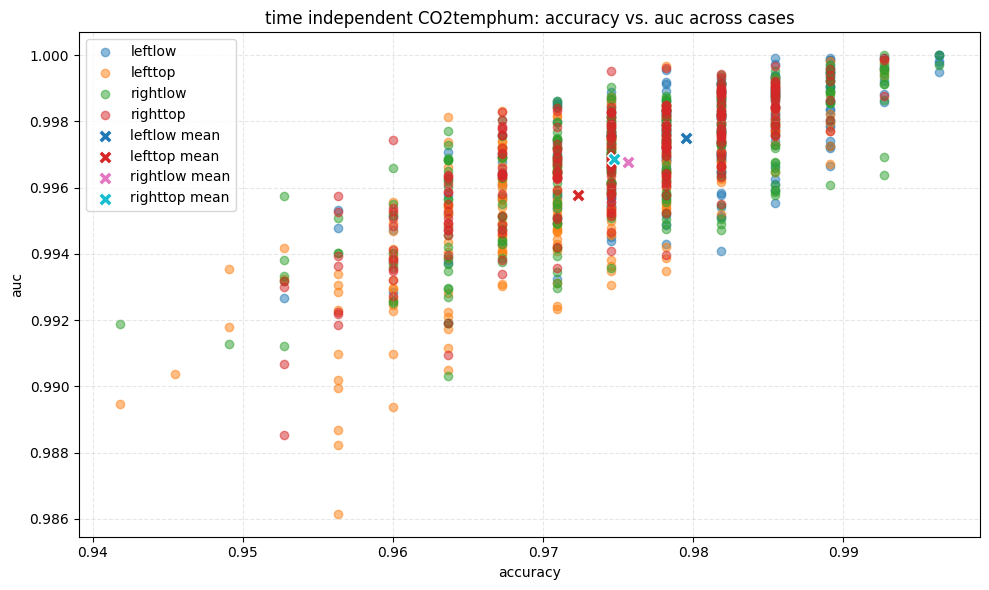

In [54]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

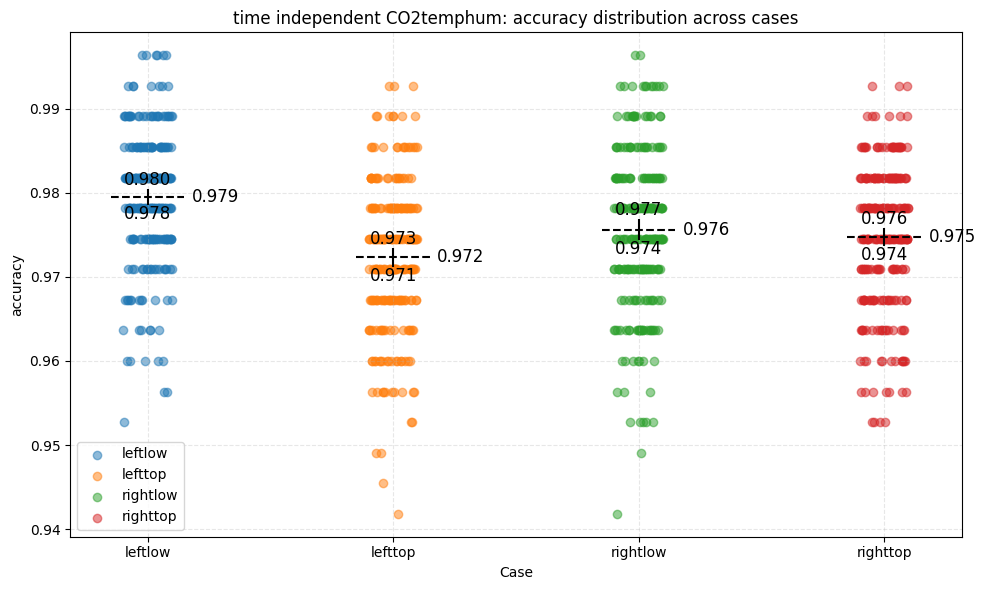

In [55]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

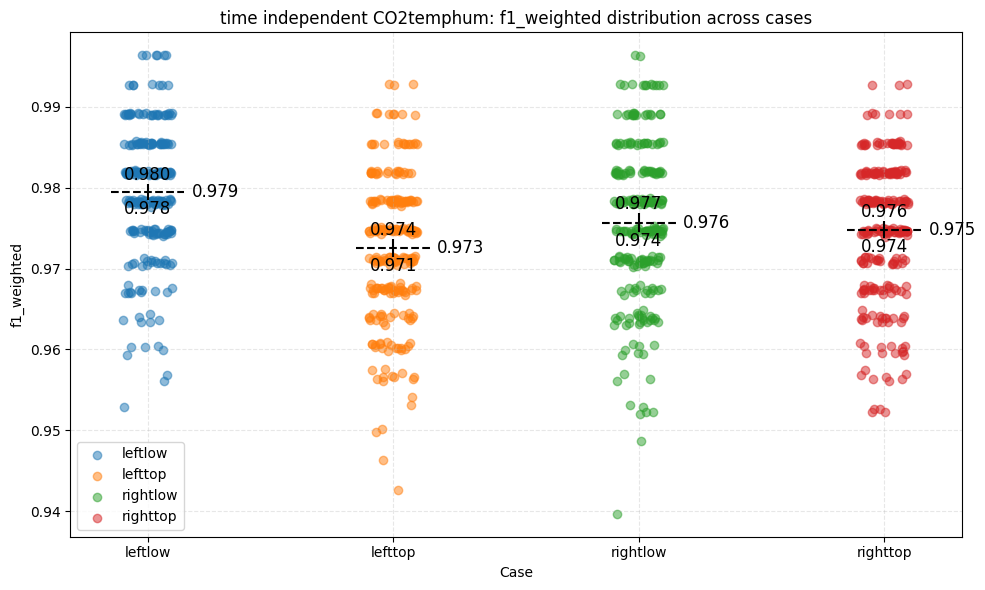

In [56]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

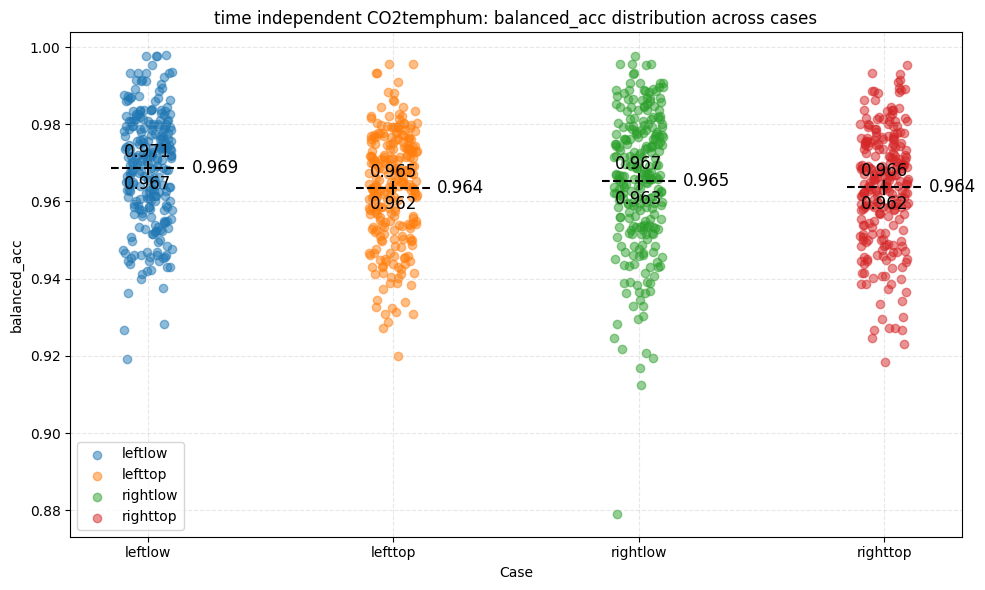

In [57]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

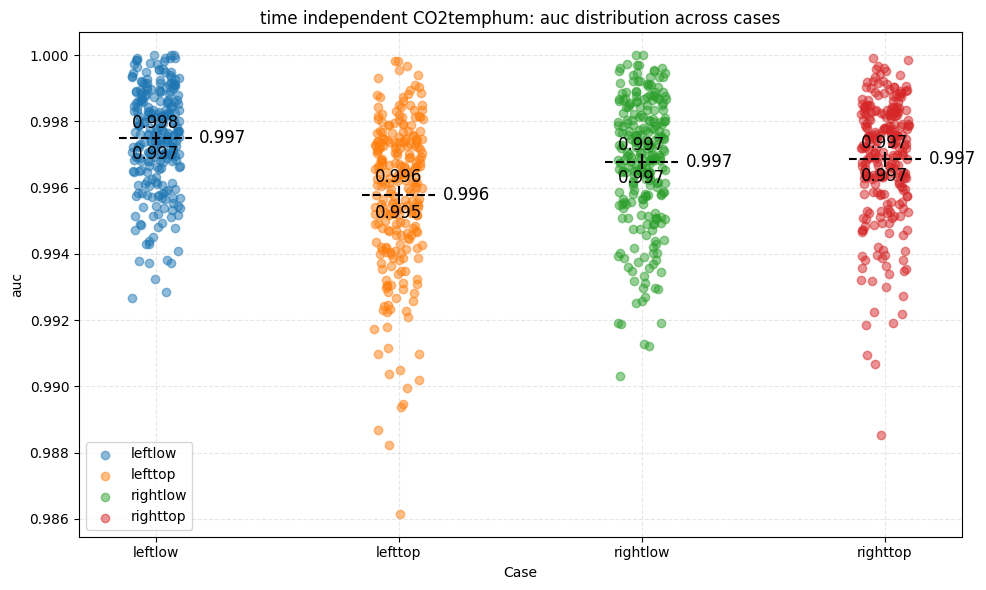

In [58]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.0025	→	not normal
lefttop                  :	p = 0.0564	→	OK normal
rightlow                 :	p = 0.0503	→	OK normal
righttop                 :	p = 0.0067	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0005	→	not normal
rightlow                 :	p = 0.0004	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 3.1709,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 2.2301,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.9645,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 3.7440,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0773	→	OK equal variances

In [60]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
leftlow                  :	p = 0.0030	→	not normal
lefttop                  :	p = 0.0848	→	OK normal
rightlow                 :	p = 0.0149	→	not normal
righttop                 :	p = 0.0065	→	not normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0052	→	not normal
rightlow                 :	p = 0.0012	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1_weighted ===
leftlow                  :	A² = 2.5810,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.5469,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.4133,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 3.0730,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.0729	→	OK eq

In [61]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0276	→	not normal
lefttop                  :	p = 0.0257	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0093	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0049	→	not normal
lefttop                  :	p = 0.0030	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0024	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 1.0728,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.5474,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.5186,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 1.1775,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0164	→	

In [62]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0005	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 1.8352,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 3.2065,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 2.6784,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 3.7297,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0001	→	unequal variances
Bartlett’s test: p

### ANOVA

In [63]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2        F        p-unc      np2
  case      3 552.306902 31.54303 7.838841e-19 0.079438

Effect size (partial η², np2) = 0.0794 → medium effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.979491 0.972320  0.007171 0.000759  9.446144 492.072313 3.363976e-14  0.843616
 leftlow rightlow 0.979491 0.975636  0.003855 0.000789  4.882453 482.896703 8.481708e-06  0.436042
 leftlow righttop 0.979491 0.974735  0.004756 0.000744  6.395335 495.397734 2.224552e-09  0.571154
 lefttop rightlow 0.972320 0.975636 -0.003316 0.000829 -4.002561 495.679329 4.189648e-04 -0.357461
 lefttop righttop 0.972320 0.974735 -0.002415 0.000785 -3.075476 497.297758 1.185871e-02 -0.274664
rightlow righttop 0.975636 0.974735  0.000902 0.000814  1.107255 492.494492 6.852363e-01  0.098887

=== Pairwise effect sizes f

In [64]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 552.324025 30.375306 3.455959e-18 0.076342

Effect size (partial η², np2) = 0.0763 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.979495 0.972512  0.006983 0.000753  9.269377 493.563925 1.961764e-13  0.827829
 leftlow rightlow 0.979495 0.975695  0.003800 0.000791  4.802052 482.440636 1.246454e-05  0.428861
 leftlow righttop 0.979495 0.974804  0.004691 0.000743  6.315887 495.662769 3.585685e-09  0.564059
 lefttop rightlow 0.972512 0.975695 -0.003183 0.000825 -3.860137 494.322629 7.388534e-04 -0.344741
 lefttop righttop 0.972512 0.974804 -0.002292 0.000778 -2.946018 497.655594 1.767695e-02 -0.263103
rightlow righttop 0.975695 0.974804  0.000891 0.000815  1.093237 491.797466 6.938490e-01  0.097635

=== Pairwise effect

In [65]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2        F   p-unc      np2
  case      3 551.765975 6.924285 0.00014 0.018302

Effect size (partial η², np2) = 0.0183 → small effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 leftlow  lefttop 0.968754 0.963517  0.005237 0.001293  4.051725 497.568202 0.000343  0.361851
 leftlow rightlow 0.968754 0.965234  0.003520 0.001460  2.410503 480.031877 0.076443  0.215277
 leftlow righttop 0.968754 0.963652  0.005102 0.001326  3.848663 497.774405 0.000772  0.343716
 lefttop rightlow 0.963517 0.965234 -0.001717 0.001443 -1.189595 474.676277 0.633731 -0.106240
 lefttop righttop 0.963517 0.963652 -0.000135 0.001307 -0.103393 496.722395 0.999604 -0.009234
rightlow righttop 0.965234 0.963652  0.001582 0.001473  1.073874 483.545586 0.705653  0.095905

=== Pairwise effect sizes for balanced_acc (Hedges' g) ===

In [66]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc     np2
  case      3 548.867057 33.115032 1.100144e-19 0.09501

Effect size (partial η², np2) = 0.0950 → medium effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.997488 0.995776  0.001712 0.000173  9.917534 439.505572 6.528111e-14  0.885715
 leftlow rightlow 0.997488 0.996791  0.000697 0.000155  4.507897 477.240195 4.868565e-05  0.402591
 leftlow righttop 0.997488 0.996854  0.000634 0.000151  4.203940 484.400294 1.827484e-04  0.375445
 lefttop rightlow 0.995776 0.996791 -0.001015 0.000187 -5.441278 484.152609 5.031298e-07 -0.485949
 lefttop righttop 0.995776 0.996854 -0.001078 0.000183 -5.880690 476.946022 4.607501e-08 -0.525192
rightlow righttop 0.996791 0.996854 -0.000063 0.000167 -0.379689 497.102369 9.813463e-01 -0.033909

=== Pairwise effect sizes for auc (He

## Time series - CO2temphum

In [67]:
model = "time series CO2temphum"
leftlow = pd.read_csv("../_timeseries_results_raw/case_room2_leftlow_state_timeseries_co2temphum.csv")
lefttop = pd.read_csv("../_timeseries_results_raw/case_room2_lefttop_state_timeseries_co2temphum.csv")
rightlow = pd.read_csv("../_timeseries_results_raw/case_room2_rightlow_state_timeseries_co2temphum.csv")
righttop = pd.read_csv("../_timeseries_results_raw/case_room2_righttop_state_timeseries_co2temphum.csv")

In [68]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.858955,0.032257,0.685714,0.840816,0.861224,0.877551,0.930612
f1,250.0,0.808233,0.065843,0.330435,0.790960,0.817217,0.845251,0.908108
balanced_acc,250.0,0.849820,0.045290,0.590189,0.831415,0.855303,0.879218,0.927110
auc,250.0,0.947695,0.015662,0.899616,0.939187,0.948103,0.958067,0.982168
feature_importance.leftlow_CO2_scaled,250.0,0.016820,0.026133,-0.031837,0.000510,0.011633,0.025612,0.179184
feature_importance.leftlow_CO2_fd1_scaled,250.0,0.004385,0.013431,-0.031837,-0.004898,0.003673,0.013878,0.043673
feature_importance.leftlow_CO2_fd2_scaled,250.0,0.004095,0.014219,-0.052653,-0.004388,0.004082,0.012245,0.054286
feature_importance.leftlow_CO2_fd3_scaled,250.0,0.006158,0.015160,-0.041224,-0.002857,0.005306,0.015510,0.045714


In [69]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.852239,0.025195,0.784861,0.832669,0.852590,0.868526,0.916335
f1,250.0,0.797073,0.039453,0.700000,0.769231,0.795812,0.825397,0.893401
balanced_acc,250.0,0.840949,0.033070,0.763775,0.817542,0.838409,0.864882,0.924802
auc,250.0,0.946364,0.014347,0.887613,0.938628,0.947019,0.955787,0.974501
feature_importance.lefttop_CO2_scaled,250.0,0.007904,0.013405,-0.028287,-0.001494,0.006375,0.015936,0.051394
feature_importance.lefttop_CO2_fd1_scaled,250.0,0.011066,0.014010,-0.025896,0.002092,0.010359,0.019124,0.052191
feature_importance.lefttop_CO2_fd2_scaled,250.0,0.011119,0.014213,-0.028287,0.002390,0.010159,0.019124,0.054980
feature_importance.lefttop_CO2_fd3_scaled,250.0,0.012459,0.014229,-0.029482,0.003685,0.009960,0.020618,0.074104


In [70]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.890629,0.015417,0.832653,0.881633,0.893878,0.902041,0.926531
f1,250.0,0.859445,0.020133,0.783069,0.848168,0.861702,0.872833,0.908163
balanced_acc,250.0,0.890737,0.017306,0.827011,0.881394,0.891198,0.900993,0.934676
auc,250.0,0.965916,0.006333,0.921569,0.963413,0.966645,0.969452,0.977550
feature_importance.rightlow_CO2_scaled,250.0,-0.012823,0.008460,-0.034694,-0.018367,-0.012245,-0.006939,0.014694
feature_importance.rightlow_CO2_fd1_scaled,250.0,0.017528,0.009045,-0.005306,0.011837,0.016939,0.022755,0.053061
feature_importance.rightlow_CO2_fd2_scaled,250.0,0.011729,0.008971,-0.017959,0.005816,0.011837,0.017143,0.038776
feature_importance.rightlow_CO2_fd3_scaled,250.0,0.008516,0.008452,-0.011837,0.002857,0.008163,0.014286,0.047755


In [71]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.863144,0.044566,0.642023,0.852140,0.871595,0.887160,0.945525
f1,250.0,0.790198,0.116842,0.061856,0.785138,0.820647,0.849741,0.923077
balanced_acc,250.0,0.843184,0.069795,0.510244,0.828920,0.860063,0.885746,0.938340
auc,250.0,0.956761,0.015175,0.878722,0.948040,0.960145,0.967902,0.983399
feature_importance.righttop_CO2_scaled,250.0,0.012202,0.024284,-0.045136,-0.004183,0.008366,0.022568,0.122179
feature_importance.righttop_CO2_fd1_scaled,250.0,0.005049,0.013401,-0.048638,-0.002724,0.005058,0.012840,0.045914
feature_importance.righttop_CO2_fd2_scaled,250.0,0.005717,0.013599,-0.027237,-0.003502,0.004475,0.012451,0.062257
feature_importance.righttop_CO2_fd3_scaled,250.0,0.006987,0.014439,-0.037743,-0.001848,0.005837,0.015564,0.052918


In [72]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [73]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.828571,0.897959,0.84898,0.853061,0.861224
f1,0.734177,0.861878,0.79558,0.804348,0.836538
balanced_acc,0.789074,0.887965,0.835749,0.84335,0.878055
auc,0.935493,0.975987,0.905655,0.947641,0.94075
x,0,0,0,0,0
x_jitter,-0.026743,0.098451,0.05468,0.09911,-0.081269


### plot

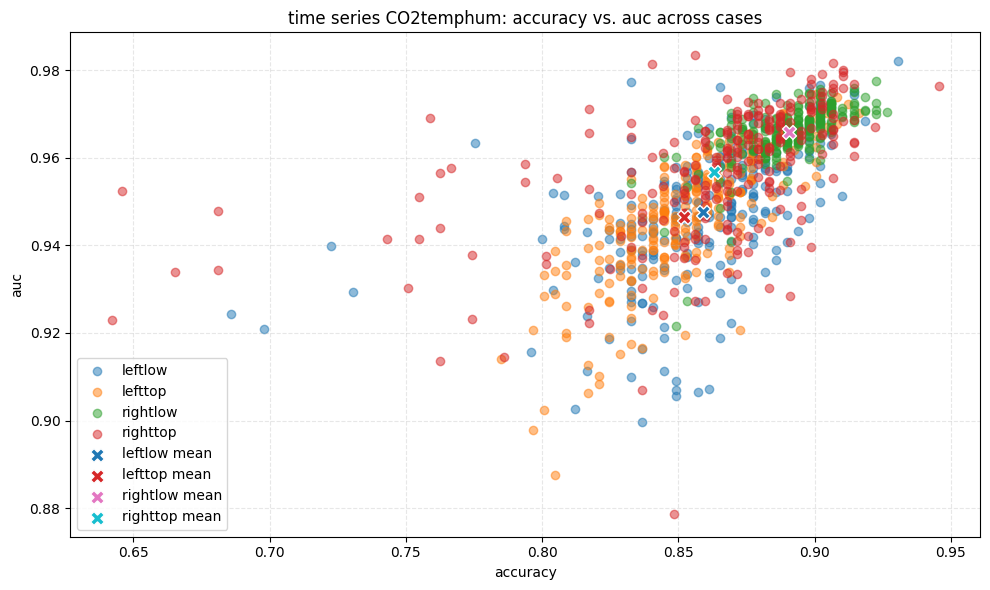

In [74]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

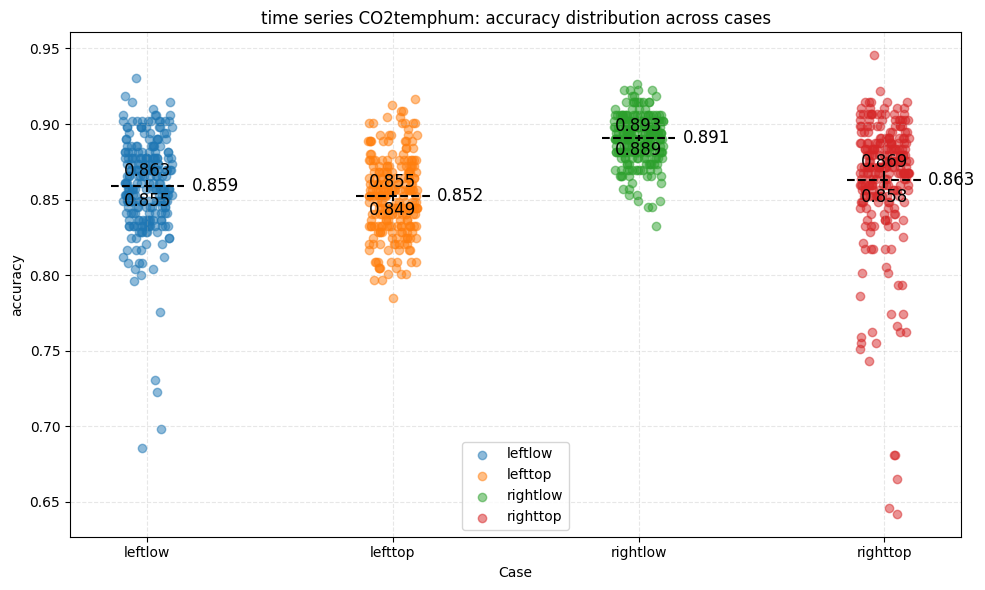

In [75]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

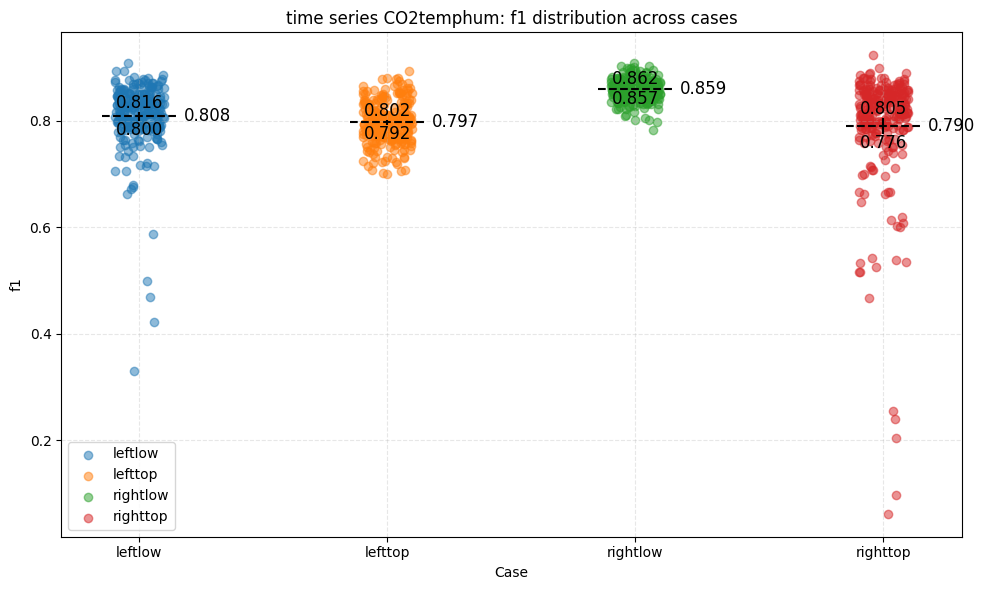

In [76]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

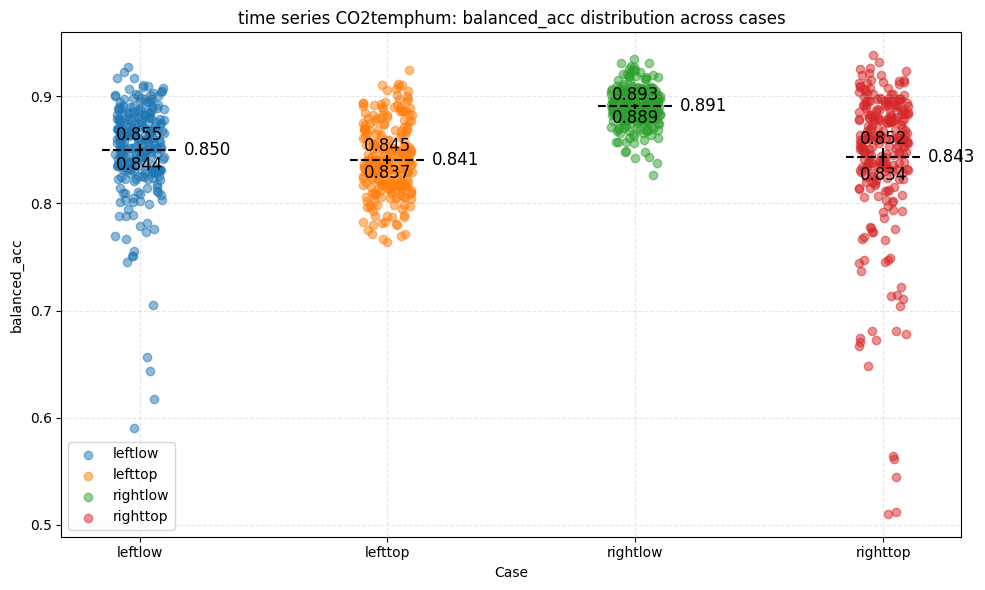

In [77]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

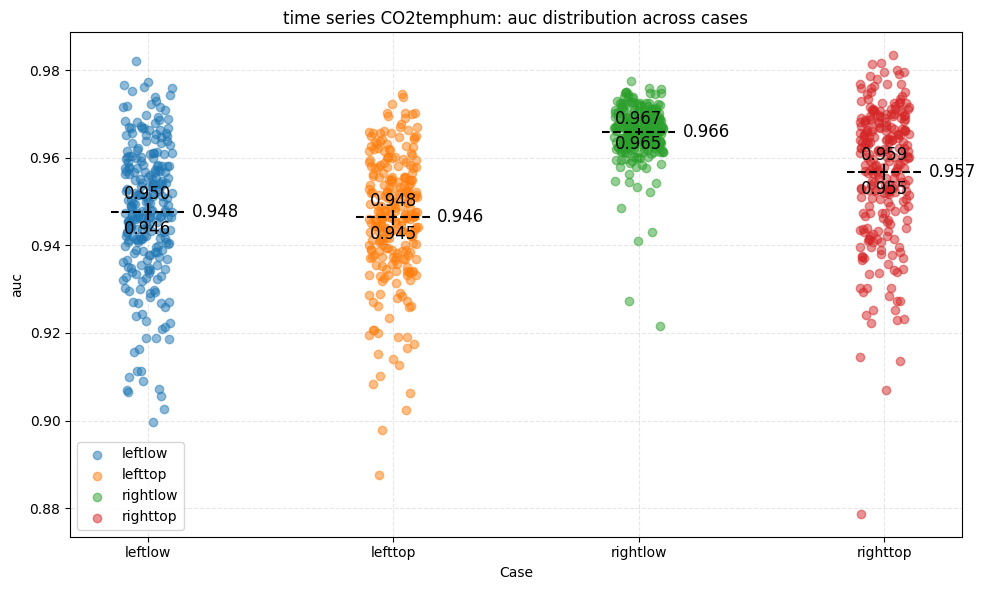

In [78]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.7382	→	OK normal
rightlow                 :	p = 0.0001	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.3772	→	OK normal
rightlow                 :	p = 0.0001	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 2.9795,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 0.4588,	5% critical = 0.7750	→	OK normal
rightlow                 :	A² = 2.1669,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 13.5291,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartl

In [80]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.4608	→	OK normal
rightlow                 :	p = 0.0002	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.3136	→	OK normal
rightlow                 :	p = 0.0011	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
leftlow                  :	A² = 13.5067,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 0.3523,	5% critical = 0.7750	→	OK normal
rightlow                 :	A² = 1.2316,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 26.2224,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	

In [81]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.1468	→	OK normal
rightlow                 :	p = 0.0025	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0943	→	OK normal
rightlow                 :	p = 0.0035	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 6.4398,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 0.7021,	5% critical = 0.7750	→	OK normal
rightlow                 :	A² = 1.1938,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 13.6850,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0000	→	unequal

In [82]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0008	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0004	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0000	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 1.2441,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.6350,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 6.4644,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 3.7883,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.

### ANOVA

In [83]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 517.309485 178.866163 1.499138e-79 0.180175

Effect size (partial η², np2) = 0.1802 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.858955 0.852239  0.006716 0.002589   2.594409 470.409868 4.791543e-02  0.231701
 leftlow rightlow 0.858955 0.890629 -0.031673 0.002261 -14.007663 357.119810 1.442180e-13 -1.250996
 leftlow righttop 0.858955 0.863144 -0.004189 0.003479  -1.203896 453.714051 6.246790e-01 -0.107518
 lefttop rightlow 0.852239 0.890629 -0.038390 0.001868 -20.549690 412.542825 8.681944e-14 -1.835251
 lefttop righttop 0.852239 0.863144 -0.010905 0.003238  -3.367980 393.416335 4.602159e-03 -0.300787
rightlow righttop 0.890629 0.863144  0.027485 0.002982   9.215387 307.758257 3.730349e-14  0.823007

=== Pairwise effect si

In [84]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2temphum

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 485.791792 208.195495 8.258690e-87 0.129326

Effect size (partial η², np2) = 0.1293 → medium effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.808233 0.797073  0.011160 0.004855   2.298776 407.382208 9.997945e-02  0.205299
 leftlow rightlow 0.808233 0.859445 -0.051212 0.004355 -11.760564 295.157042 0.000000e+00 -1.050312
 leftlow righttop 0.808233 0.790198  0.018035 0.008482   2.126172 392.657059 1.465961e-01  0.189884
 lefttop rightlow 0.797073 0.859445 -0.062372 0.002801 -22.265307 370.447495 1.458833e-13 -1.988469
 lefttop righttop 0.797073 0.790198  0.006875 0.007800   0.881470 305.050259 8.144848e-01  0.078722
rightlow righttop 0.859445 0.790198  0.069247 0.007499   9.234676 263.772642 1.987299e-14  0.824730

=== Pairwise effect sizes for f1 

In [85]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 497.735621 199.690268 5.323056e-85 0.164909

Effect size (partial η², np2) = 0.1649 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.849820 0.840949  0.008871 0.003547   2.501302 455.750282 6.103335e-02  0.223386
 leftlow rightlow 0.849820 0.890737 -0.040917 0.003066 -13.343914 320.195156 0.000000e+00 -1.191718
 leftlow righttop 0.849820 0.843184  0.006636 0.005262   1.261154 427.112726 5.882235e-01  0.112631
 lefttop rightlow 0.840949 0.890737 -0.049789 0.002361 -21.091318 375.860970 6.328271e-14 -1.883622
 lefttop righttop 0.840949 0.843184 -0.002235 0.004885  -0.457570 355.439860 9.681208e-01 -0.040865
rightlow righttop 0.890737 0.843184  0.047553 0.004548  10.456212 279.501797 0.000000e+00  0.933823

=== Pairwise e

In [86]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      3 504.811878 202.083329 4.434587e-86 0.256217

Effect size (partial η², np2) = 0.2562 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.947695 0.946364  0.001331 0.001343   0.990697 494.221409 7.548168e-01  0.088477
 leftlow rightlow 0.947695 0.965916 -0.018222 0.001068 -17.054377 328.302140 0.000000e+00 -1.523091
 leftlow righttop 0.947695 0.956761 -0.009066 0.001379  -6.573352 497.504858 7.466158e-10 -0.587053
 lefttop rightlow 0.946364 0.965916 -0.019552 0.000992 -19.712931 342.476968 0.000000e+00 -1.760521
 lefttop righttop 0.946364 0.956761 -0.010397 0.001321  -7.871780 496.440614 3.952394e-14 -0.703013
rightlow righttop 0.965916 0.956761  0.009155 0.001040   8.803460 333.173858 5.306866e-14  0.786219

=== Pairwise effect sizes for au

## Time independent - temphum

In [87]:
model = "time independent temphum"
leftlow = pd.read_csv("../_timeindep_results_raw/case_room2_leftlow_state_timeindep_temphum.csv")
lefttop = pd.read_csv("../_timeindep_results_raw/case_room2_lefttop_state_timeindep_temphum.csv")
rightlow = pd.read_csv("../_timeindep_results_raw/case_room2_rightlow_state_timeindep_temphum.csv")
righttop = pd.read_csv("../_timeindep_results_raw/case_room2_righttop_state_timeindep_temphum.csv")

In [88]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.962080,0.010022,0.934545,0.956364,0.963636,0.967273,0.989091
f1_weighted,250.0,0.962450,0.009846,0.934545,0.956186,0.963636,0.968040,0.989122
balanced_acc,250.0,0.951031,0.016847,0.904998,0.940213,0.952561,0.963036,0.987241
auc,250.0,0.990246,0.004220,0.974905,0.988082,0.990750,0.993095,0.999318
model_weights.random_forest,250.0,1.777745,0.368176,0.893649,1.505342,1.764619,2.008865,2.969823
model_weights.bagging_svc,250.0,3.100158,0.254445,2.442342,2.920164,3.099405,3.276016,3.922112
model_weights.bagging_knn,250.0,0.619642,0.317723,-0.274038,0.396156,0.599714,0.823561,1.504503
model_weights.gradient_boosting,250.0,1.943158,0.383483,0.906659,1.679027,1.932732,2.218902,3.262275


In [89]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.961571,0.010361,0.930909,0.956364,0.960000,0.970909,0.985455
f1_weighted,250.0,0.962102,0.010127,0.932537,0.956364,0.961245,0.970909,0.985648
balanced_acc,250.0,0.954599,0.016755,0.905210,0.942392,0.956811,0.967603,0.990950
auc,250.0,0.991553,0.003808,0.977889,0.989322,0.992171,0.994365,0.998430
model_weights.random_forest,250.0,2.122355,0.357995,1.169781,1.884388,2.102913,2.357343,3.581972
model_weights.bagging_svc,250.0,3.160700,0.344566,2.158753,2.953830,3.167950,3.383108,4.234549
model_weights.bagging_knn,250.0,0.578038,0.298343,-0.270122,0.399156,0.577777,0.770662,1.324639
model_weights.gradient_boosting,250.0,1.124881,0.446207,-0.225353,0.868155,1.089549,1.405635,2.704542


In [90]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.962662,0.010643,0.930909,0.956364,0.963636,0.970909,0.996364
f1_weighted,250.0,0.962942,0.010460,0.931148,0.956424,0.963860,0.970909,0.996375
balanced_acc,250.0,0.949260,0.016860,0.894042,0.938252,0.951546,0.960221,0.997696
auc,250.0,0.992681,0.003302,0.981733,0.990959,0.992929,0.995072,1.000000
model_weights.random_forest,250.0,2.182947,0.454005,0.981831,1.833483,2.162726,2.541332,3.627187
model_weights.bagging_svc,250.0,2.730886,0.381960,1.538046,2.483132,2.740696,3.017575,3.723668
model_weights.bagging_knn,250.0,0.980863,0.345799,0.145045,0.724397,0.989702,1.220252,1.894928
model_weights.gradient_boosting,250.0,1.074464,0.454477,-0.319251,0.772020,1.082750,1.391659,2.269029


In [91]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.961338,0.010636,0.927273,0.952727,0.963636,0.967273,0.989091
f1_weighted,250.0,0.961697,0.010445,0.929628,0.953842,0.963375,0.967755,0.989120
balanced_acc,250.0,0.949401,0.016654,0.900388,0.938630,0.949176,0.961012,0.991031
auc,250.0,0.990450,0.003928,0.971799,0.987861,0.990763,0.993390,0.998808
model_weights.random_forest,250.0,2.527180,0.406355,1.654036,2.239546,2.530231,2.792369,3.596403
model_weights.bagging_svc,250.0,3.132298,0.178646,2.605142,3.014154,3.136902,3.245778,3.613803
model_weights.bagging_knn,250.0,1.290774,0.326152,0.492333,1.092151,1.288594,1.526450,2.155829
model_weights.gradient_boosting,250.0,1.323601,0.417784,0.274037,1.062130,1.284550,1.600720,2.544214


In [92]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1_weighted   1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [93]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.967273,0.96,0.970909,0.934545,0.981818
f1_weighted,0.967612,0.959858,0.971084,0.935352,0.981768
balanced_acc,0.958185,0.933132,0.963002,0.913367,0.971823
auc,0.989886,0.991202,0.988779,0.988492,0.996742
x,0,0,0,0,0
x_jitter,0.04154,-0.028617,0.083327,0.082701,0.07774


### plot

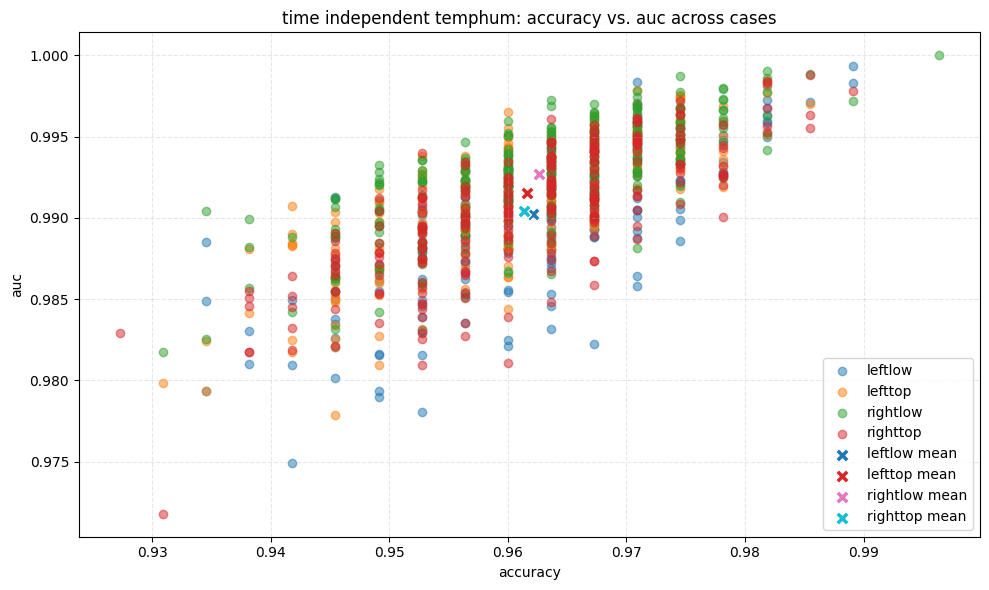

In [94]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

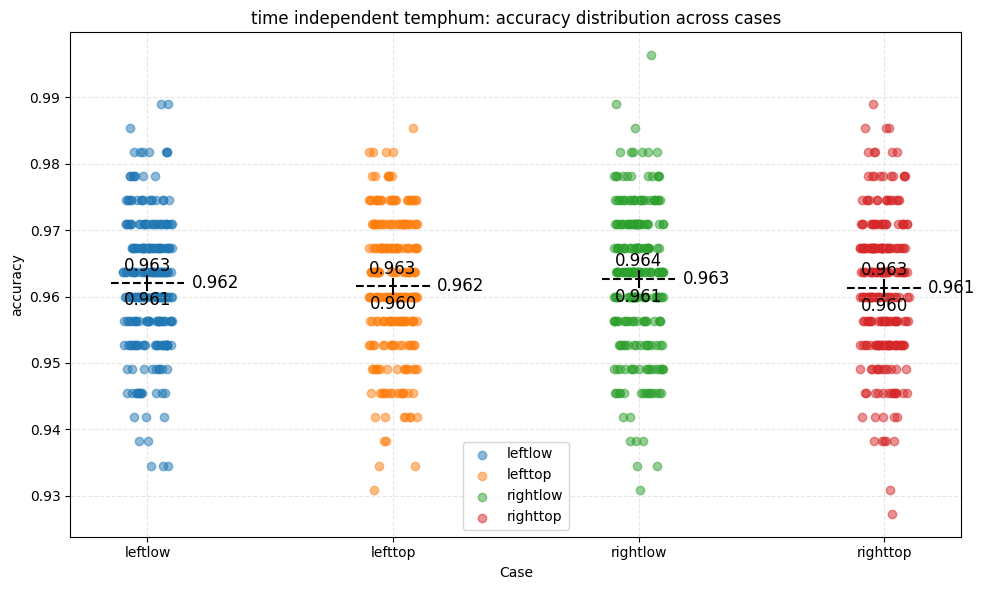

In [95]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

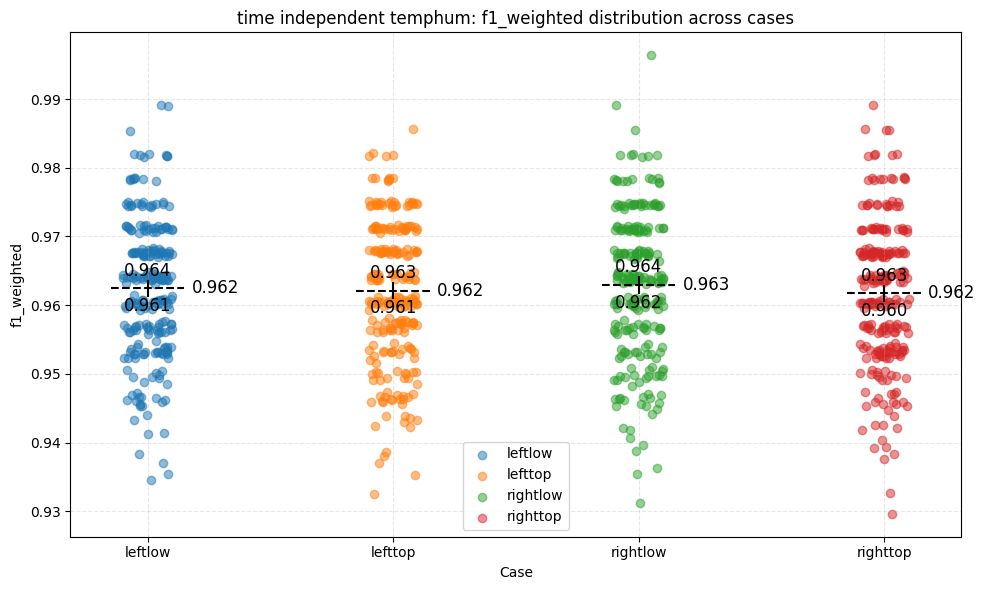

In [96]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

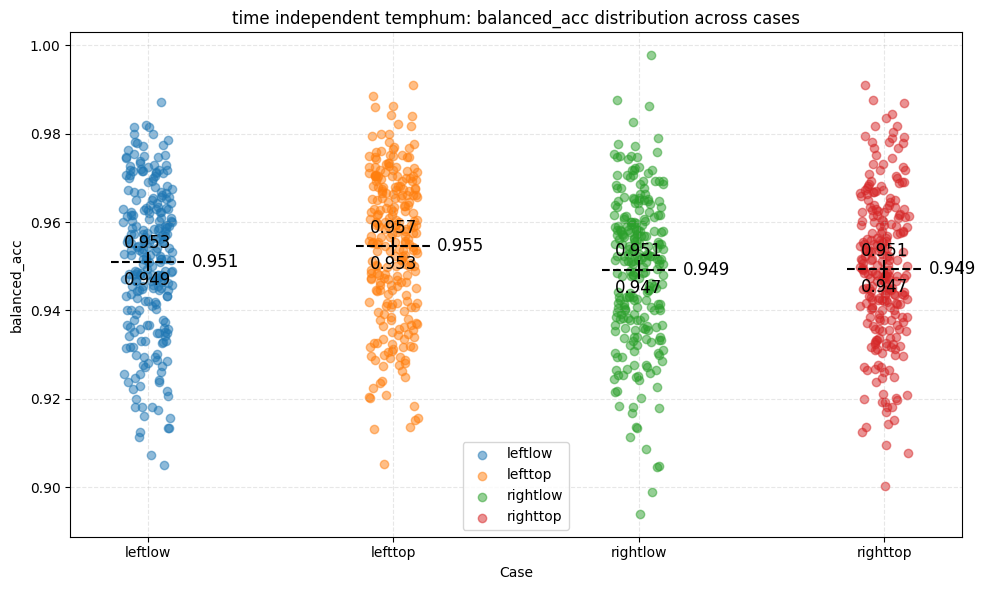

In [97]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

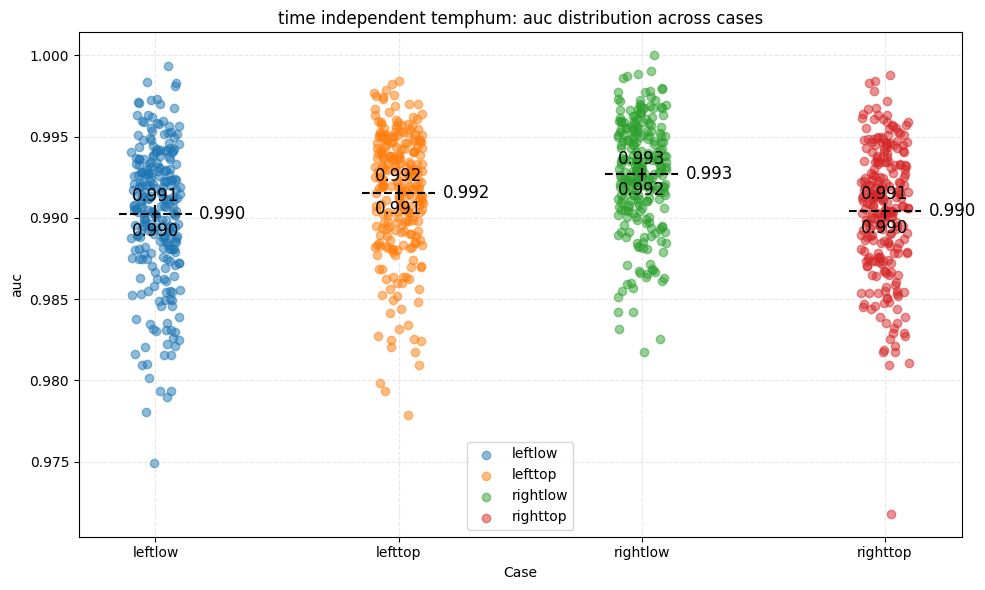

In [98]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.6530	→	OK normal
lefttop                  :	p = 0.0533	→	OK normal
rightlow                 :	p = 0.3296	→	OK normal
righttop                 :	p = 0.5046	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0115	→	not normal
lefttop                  :	p = 0.0004	→	not normal
rightlow                 :	p = 0.0047	→	not normal
righttop                 :	p = 0.0165	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 1.5127,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 2.1429,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.8115,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 1.5329,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.7359	→	OK equal variances
Bart

In [100]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
leftlow                  :	p = 0.7666	→	OK normal
lefttop                  :	p = 0.0522	→	OK normal
rightlow                 :	p = 0.3749	→	OK normal
righttop                 :	p = 0.6531	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
leftlow                  :	p = 0.2805	→	OK normal
lefttop                  :	p = 0.0037	→	not normal
rightlow                 :	p = 0.0808	→	OK normal
righttop                 :	p = 0.2565	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
leftlow                  :	A² = 0.6609,	5% critical = 0.7750	→	OK normal
lefttop                  :	A² = 1.4417,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.0321,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 0.7796,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1_weighted ===
Levene’s test  : p = 0.7584	→	OK equal varian

In [101]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0186	→	not normal
lefttop                  :	p = 0.0094	→	not normal
rightlow                 :	p = 0.0259	→	not normal
righttop                 :	p = 0.7429	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0033	→	not normal
lefttop                  :	p = 0.0009	→	not normal
rightlow                 :	p = 0.0372	→	not normal
righttop                 :	p = 0.8963	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 1.1070,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 1.7936,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.9344,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 0.1608,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.9565	→	OK equ

In [102]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0001	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0003	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0002	→	not normal
righttop                 :	p = 0.0001	→	not normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 2.0862,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 3.1059,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.6502,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 1.0949,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0115	→	unequal variances
Bartlett’s test: p = 

### ANOVA

In [103]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2       F    p-unc     np2
  case      3 553.180315 0.76806 0.512239 0.00239

Effect size (partial η², np2) = 0.0024 → negligible effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 leftlow  lefttop 0.962080 0.961571  0.000509 0.000912  0.558429 497.449634 0.944226  0.049872
 leftlow rightlow 0.962080 0.962662 -0.000582 0.000925 -0.629285 496.207948 0.922610 -0.056200
 leftlow righttop 0.962080 0.961338  0.000742 0.000924  0.802627 496.248004 0.853187  0.071681
 lefttop rightlow 0.961571 0.962662 -0.001091 0.000939 -1.161281 497.640244 0.651583 -0.103712
 lefttop righttop 0.961571 0.961338  0.000233 0.000939  0.247827 497.658193 0.994650  0.022133
rightlow righttop 0.962662 0.961338  0.001324 0.000952  1.390925 497.999770 0.505616  0.124221

=== Pairwise effect sizes for accuracy (Hedges' g) ===
leftlow    

In [104]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2        F    p-unc      np2
  case      3 553.177547 0.641242 0.588727 0.002007

Effect size (partial η², np2) = 0.0020 → negligible effect

=== Games-Howell post-hoc test for f1_weighted ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 leftlow  lefttop 0.962450 0.962102  0.000348 0.000893  0.389301 497.606262 0.979949  0.034768
 leftlow rightlow 0.962450 0.962942 -0.000492 0.000909 -0.541775 496.190760 0.948724 -0.048385
 leftlow righttop 0.962450 0.961697  0.000753 0.000908  0.829172 496.275297 0.840614  0.074052
 lefttop rightlow 0.962102 0.962942 -0.000840 0.000921 -0.912240 497.480671 0.798335 -0.081470
 lefttop righttop 0.962102 0.961697  0.000405 0.000920  0.440140 497.525774 0.971474  0.039308
rightlow righttop 0.962942 0.961697  0.001245 0.000935  1.331684 497.998971 0.543137  0.118930

=== Pairwise effect sizes for f1_weighted (Hedges' g) ==

In [105]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2        F    p-unc     np2
  case      3 553.327275 5.481244 0.001023 0.01624

Effect size (partial η², np2) = 0.0162 → small effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se         T         df     pval    hedges
 leftlow  lefttop 0.951031 0.954599 -0.003568 0.001503 -2.374139 497.985112 0.083429 -0.212030
 leftlow rightlow 0.951031 0.949260  0.001771 0.001507  1.174814 497.999683 0.643060  0.104920
 leftlow righttop 0.951031 0.949401  0.001631 0.001498  1.088300 497.933658 0.696867  0.097194
 lefttop rightlow 0.954599 0.949260  0.005339 0.001503  3.551206 497.980452 0.002366  0.317151
 lefttop righttop 0.954599 0.949401  0.005198 0.001494  3.479183 497.981620 0.003063  0.310719
rightlow righttop 0.949260 0.949401 -0.000140 0.001499 -0.093708 497.924177 0.999705 -0.008369

=== Pairwise effect sizes for balanced_acc (Hedges' g) ===
le

In [106]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 551.198834 23.727513 1.865950e-14 0.060883

Effect size (partial η², np2) = 0.0609 → medium effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
 leftlow  lefttop 0.990246 0.991553 -0.001307 0.000359 -3.636439 492.856976 1.732842e-03 -0.324763
 leftlow rightlow 0.990246 0.992681 -0.002435 0.000339 -7.185222 470.776147 1.599920e-11 -0.641697
 leftlow righttop 0.990246 0.990450 -0.000203 0.000365 -0.558092 495.477124 9.443194e-01 -0.049842
 lefttop rightlow 0.991553 0.992681 -0.001127 0.000319 -3.536865 488.183334 2.495618e-03 -0.315870
 lefttop righttop 0.991553 0.990450  0.001104 0.000346  3.189689 497.521214 8.220418e-03  0.284865
rightlow righttop 0.992681 0.990450  0.002231 0.000325  6.874819 483.679285 1.155767e-10  0.613976

=== Pairwise effect sizes for auc (Hed

## Time series - temphum

In [107]:
model = "time series temphum"
leftlow = pd.read_csv("../_timeseries_results_raw/case_room2_leftlow_state_timeseries_temphum.csv")
lefttop = pd.read_csv("../_timeseries_results_raw/case_room2_lefttop_state_timeseries_temphum.csv")
rightlow = pd.read_csv("../_timeseries_results_raw/case_room2_rightlow_state_timeseries_temphum.csv")
righttop = pd.read_csv("../_timeseries_results_raw/case_room2_righttop_state_timeseries_temphum.csv")

In [108]:
leftlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.839079,0.034785,0.656904,0.824268,0.845188,0.861925,0.895397
f1,250.0,0.791206,0.076489,0.196078,0.775997,0.806452,0.829016,0.872549
balanced_acc,250.0,0.835209,0.049035,0.554348,0.817999,0.844628,0.865378,0.905464
auc,250.0,0.920541,0.019984,0.790964,0.908847,0.922064,0.933563,0.959701
feature_importance.leftlow_temperature_scaled,250.0,-0.005628,0.017859,-0.052301,-0.016213,-0.006276,0.006590,0.048536
feature_importance.leftlow_temperature_fd1_scaled,250.0,0.004895,0.019135,-0.046444,-0.005858,0.003556,0.012971,0.078243
feature_importance.leftlow_temperature_fd2_scaled,250.0,0.006731,0.019676,-0.043096,-0.005021,0.005649,0.017573,0.094979
feature_importance.leftlow_temperature_fd3_scaled,250.0,0.003225,0.019300,-0.046025,-0.009937,0.002510,0.014644,0.067782


In [109]:
lefttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.809021,0.028310,0.615063,0.794979,8.117155e-01,0.824268,0.870293
f1,250.0,0.744116,0.070087,0.000000,0.730494,7.480390e-01,0.775178,0.838095
balanced_acc,250.0,0.795515,0.037892,0.500000,0.782535,7.954377e-01,0.817168,0.876220
auc,250.0,0.919756,0.016017,0.873041,0.910474,9.226190e-01,0.931455,0.951124
feature_importance.lefttop_temperature_scaled,250.0,0.009272,0.022799,-0.054393,-0.005439,9.414226e-03,0.023849,0.077406
feature_importance.lefttop_temperature_fd1_scaled,250.0,0.001722,0.020762,-0.047699,-0.011192,5.551115e-17,0.014435,0.075732
feature_importance.lefttop_temperature_fd2_scaled,250.0,0.001871,0.021118,-0.046025,-0.011925,1.110223e-16,0.013389,0.059414
feature_importance.lefttop_temperature_fd3_scaled,250.0,0.001530,0.019792,-0.053975,-0.011192,-2.092050e-04,0.015063,0.057741


In [110]:
rightlow.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.837255,0.020424,0.786611,0.824268,0.836820,0.849372,0.907950
f1,250.0,0.794924,0.028845,0.719101,0.775622,0.793814,0.813678,0.888889
balanced_acc,250.0,0.834556,0.024743,0.772996,0.817815,0.833426,0.850442,0.917036
auc,250.0,0.943620,0.008974,0.912378,0.937297,0.942805,0.949479,0.975895
feature_importance.rightlow_temperature_scaled,250.0,0.004564,0.017586,-0.053138,-0.007950,0.004393,0.016213,0.052301
feature_importance.rightlow_temperature_fd1_scaled,250.0,0.001180,0.014552,-0.035146,-0.009833,0.002092,0.011192,0.037238
feature_importance.rightlow_temperature_fd2_scaled,250.0,0.002606,0.015338,-0.035983,-0.009100,0.002510,0.012448,0.044351
feature_importance.rightlow_temperature_fd3_scaled,250.0,0.003428,0.014507,-0.037238,-0.006695,0.002929,0.013285,0.040586


In [111]:
righttop.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.833088,0.020635,0.719665,0.824268,0.836820,0.845188,0.878661
f1,250.0,0.787001,0.040899,0.480620,0.777638,0.795865,0.807631,0.846561
balanced_acc,250.0,0.828793,0.029955,0.648070,0.819515,0.835145,0.844979,0.880324
auc,250.0,0.920337,0.012622,0.875998,0.911602,0.920770,0.929644,0.949793
feature_importance.righttop_temperature_scaled,250.0,0.003541,0.015999,-0.048954,-0.002824,0.006067,0.014226,0.040586
feature_importance.righttop_temperature_fd1_scaled,250.0,0.006730,0.015105,-0.031799,-0.002092,0.003347,0.015063,0.068619
feature_importance.righttop_temperature_fd2_scaled,250.0,0.008395,0.015514,-0.029707,-0.001569,0.005858,0.017573,0.061088
feature_importance.righttop_temperature_fd3_scaled,250.0,0.008251,0.014437,-0.023849,-0.002092,0.006276,0.016736,0.068201


In [112]:
leftlow['case'] = 'leftlow'
lefttop['case'] = 'lefttop'
rightlow['case'] = 'rightlow'
righttop['case'] = 'righttop'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        leftlow[metrics],
        lefttop[metrics],
        rightlow[metrics],
        righttop[metrics]
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1000 non-null   object 
 1   accuracy      1000 non-null   float64
 2   f1            1000 non-null   float64
 3   balanced_acc  1000 non-null   float64
 4   auc           1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [113]:
case_order = ['leftlow', 'lefttop', 'rightlow', 'righttop']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,leftlow,leftlow,leftlow,leftlow,leftlow
accuracy,0.824268,0.841004,0.845188,0.828452,0.786611
f1,0.785714,0.802083,0.80829,0.803828,0.732984
balanced_acc,0.826642,0.840247,0.845682,0.844277,0.781795
auc,0.920734,0.893671,0.914818,0.927462,0.914966
x,0,0,0,0,0
x_jitter,0.099014,-0.026868,0.028628,-0.080741,0.099267


### plot

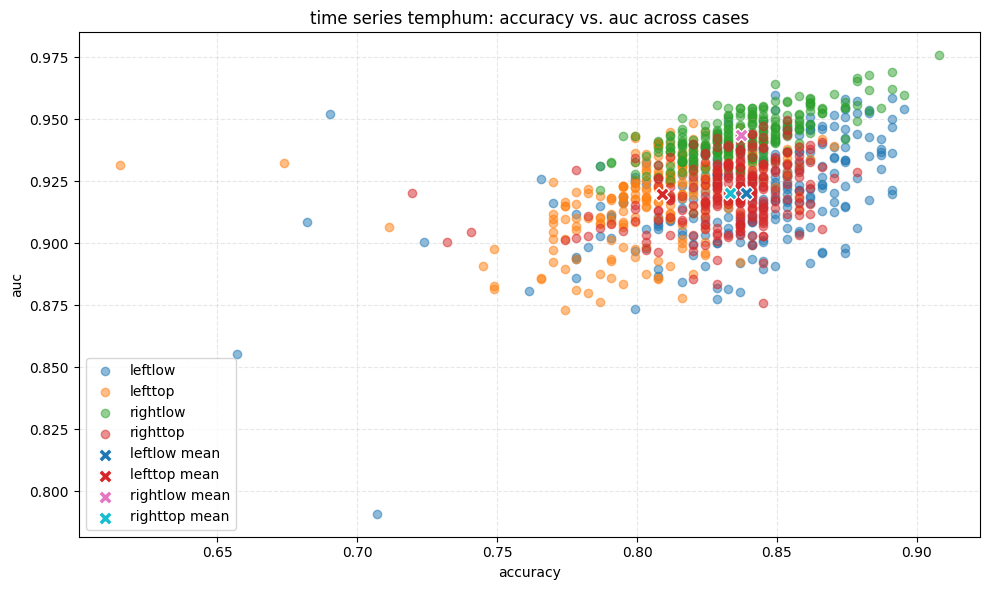

In [114]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

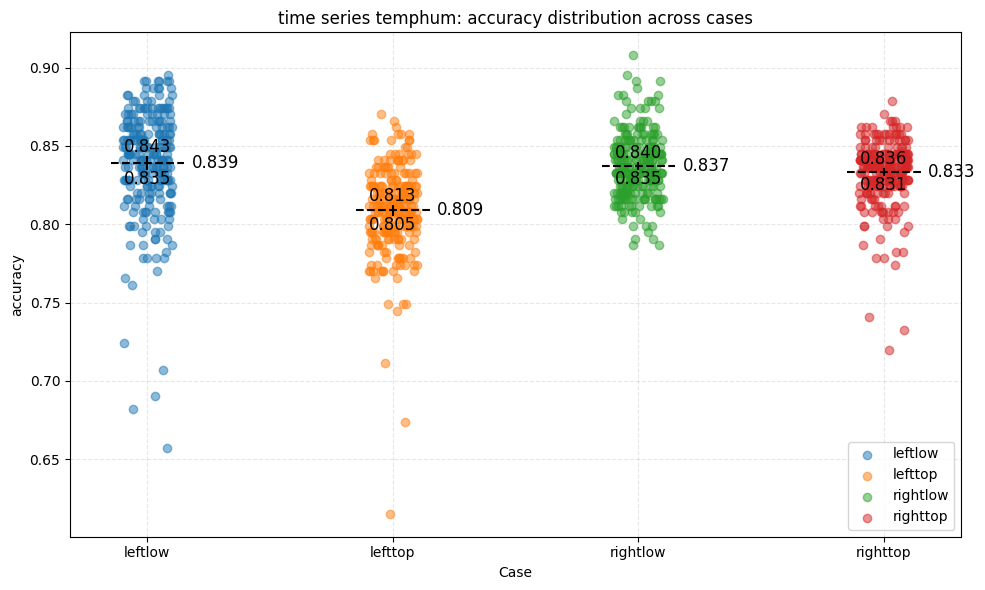

In [115]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

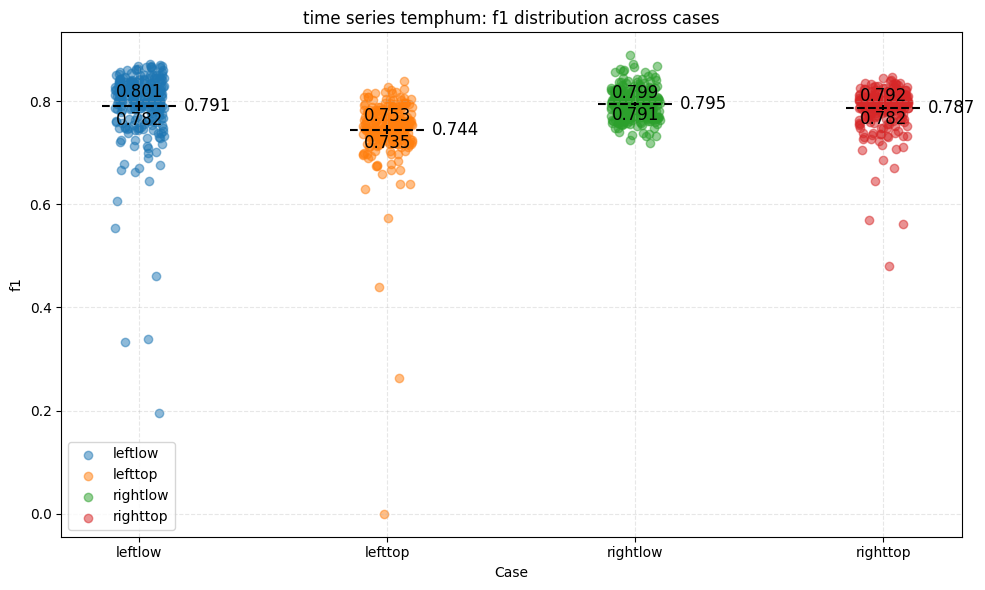

In [116]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

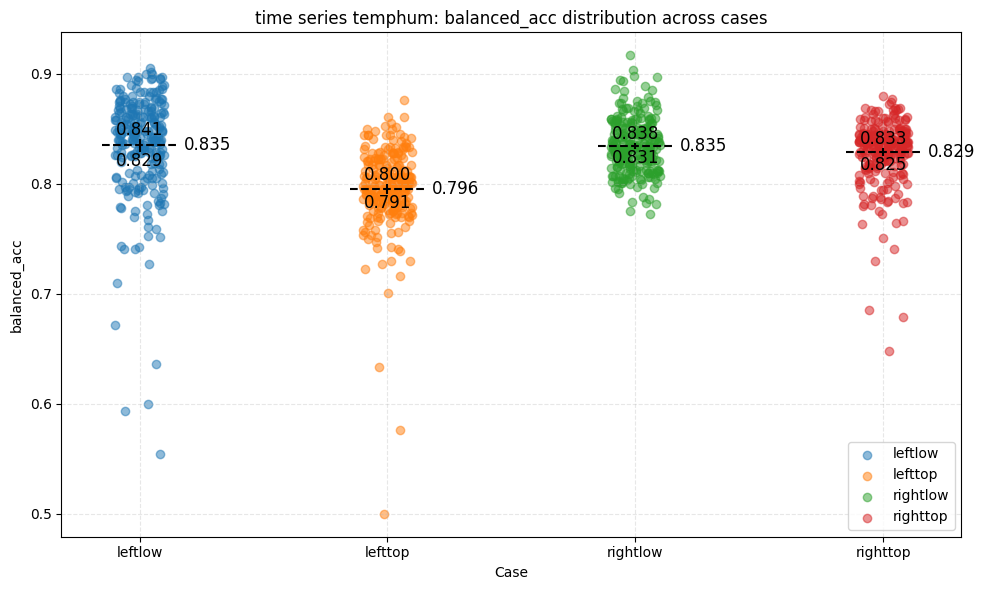

In [117]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

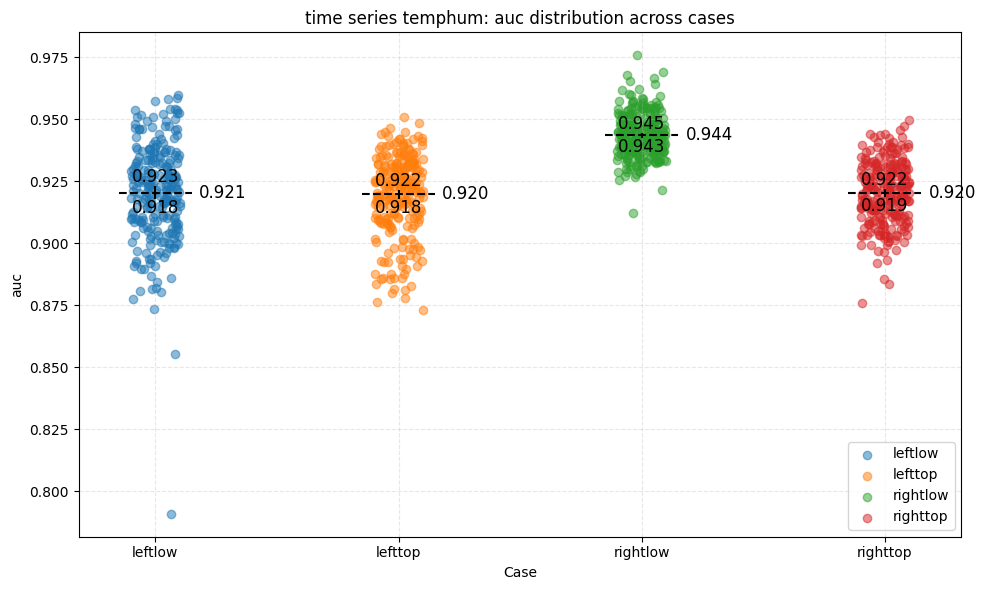

In [118]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [119]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0108	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0059	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
leftlow                  :	A² = 4.1645,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 3.0574,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 1.2216,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 6.6198,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for accuracy ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartle

In [120]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.1660	→	OK normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.3695	→	OK normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
leftlow                  :	A² = 17.4843,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 20.9087,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.4292,	5% critical = 0.7750	→	OK normal
righttop                 :	A² = 14.0038,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for f1 ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→	

In [121]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0464	→	not normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.1011	→	OK normal
righttop                 :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
leftlow                  :	A² = 7.6377,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 6.5064,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.6133,	5% critical = 0.7750	→	OK normal
righttop                 :	A² = 9.1171,	5% critical = 0.7750	→	not normal

=== Homogeneity of variance tests for balanced_acc ===
Levene’s test  : p = 0.0000	→	unequal va

In [122]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0001	→	not normal
rightlow                 :	p = 0.0161	→	not normal
righttop                 :	p = 0.2353	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
leftlow                  :	p = 0.0000	→	not normal
lefttop                  :	p = 0.0000	→	not normal
rightlow                 :	p = 0.0230	→	not normal
righttop                 :	p = 0.1790	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
leftlow                  :	A² = 0.9493,	5% critical = 0.7750	→	not normal
lefttop                  :	A² = 3.5626,	5% critical = 0.7750	→	not normal
rightlow                 :	A² = 0.9117,	5% critical = 0.7750	→	not normal
righttop                 :	A² = 0.3120,	5% critical = 0.7750	→	OK normal

=== Homogeneity of variance tests for auc ===
Levene’s test  : p = 0.0000	→	unequal variances
Bartlett’s test: p = 0.0000	→

### ANOVA

In [123]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 543.597616 63.230304 4.422855e-35 0.170442

Effect size (partial η², np2) = 0.1704 → large effect

=== Games-Howell post-hoc test for accuracy ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.839079 0.809021  0.030059 0.002837  10.596965 478.270108 1.763034e-13  0.946393
 leftlow rightlow 0.839079 0.837255  0.001824 0.002551   0.715060 402.450154 8.910984e-01  0.063861
 leftlow righttop 0.839079 0.833088  0.005992 0.002558   2.342341 404.933058 9.031473e-02  0.209190
 lefttop rightlow 0.809021 0.837255 -0.028234 0.002208 -12.788298 452.952843 1.709743e-14 -1.142097
 lefttop righttop 0.809021 0.833088 -0.024067 0.002216 -10.862347 455.334305 0.000000e+00 -0.970094
rightlow righttop 0.837255 0.833088  0.004167 0.001836   2.269502 497.947772 1.066157e-01  0.202685

=== Pairwise effect sizes f

In [124]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series temphum

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 519.588244 37.555389 5.581116e-22 0.112977

Effect size (partial η², np2) = 0.1130 → medium effect

=== Games-Howell post-hoc test for f1 ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.791206 0.744116  0.047090 0.006561   7.176915 494.242188 1.582856e-11  0.640956
 leftlow rightlow 0.791206 0.794924 -0.003718 0.005170  -0.719098 318.418494 8.894581e-01 -0.064221
 leftlow righttop 0.791206 0.787001  0.004205 0.005486   0.766528 380.623319 8.694847e-01  0.068457
 lefttop rightlow 0.744116 0.794924 -0.050808 0.004793 -10.599555 331.000526 2.042810e-14 -0.946625
 lefttop righttop 0.744116 0.787001 -0.042885 0.005132  -8.356077 400.963153 0.000000e+00 -0.746264
rightlow righttop 0.794924 0.787001  0.007923 0.003165   2.503027 447.578310 6.079088e-02  0.223540

=== Pairwise effect sizes for f1 (Hedg

In [125]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      3 539.767184 67.397865 4.982426e-37 0.167298

Effect size (partial η², np2) = 0.1673 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.835209 0.795515  0.039694 0.003919  10.127923 468.211953 0.000000e+00  0.904504
 leftlow rightlow 0.835209 0.834556  0.000653 0.003474   0.188087 368.084315 9.976370e-01  0.016798
 leftlow righttop 0.835209 0.828793  0.006416 0.003634   1.765530 412.129901 2.915324e-01  0.157676
 lefttop rightlow 0.795515 0.834556 -0.039041 0.002862 -13.640243 428.680998 4.185541e-14 -1.218182
 lefttop righttop 0.795515 0.828793 -0.033278 0.003055 -10.893361 472.813280 3.708145e-13 -0.972864
rightlow righttop 0.834556 0.828793  0.005763 0.002457   2.345209 480.851219 8.944038e-02  0.209446

=== Pairwise effect

In [126]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      3 531.722915 286.146303 1.570253e-110 0.315545

Effect size (partial η², np2) = 0.3155 → large effect

=== Games-Howell post-hoc test for auc ===
       A        B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
 leftlow  lefttop 0.920541 0.919756  0.000785 0.001620   0.484545 475.457564 9.625125e-01  0.043274
 leftlow rightlow 0.920541 0.943620 -0.023079 0.001385 -16.657733 345.504982 1.114664e-13 -1.487668
 leftlow righttop 0.920541 0.920337  0.000204 0.001495   0.136324 420.393514 9.990948e-01  0.012175
 lefttop rightlow 0.919756 0.943620 -0.023864 0.001161 -20.551683 391.313786 0.000000e+00 -1.835429
 lefttop righttop 0.919756 0.920337 -0.000581 0.001290  -0.450517 472.192222 9.695109e-01 -0.040235
rightlow righttop 0.943620 0.920337  0.023282 0.000979  23.770139 449.505981 0.000000e+00  2.122862

=== Pairwise effect sizes for auc